# Still-life loop — local MiniMax H3 first/last-frame interpolation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MNoichl/FluxFlowMorph/blob/agent/chimera-flux-flat-morph/notebooks/StillLife_MiniMax_H3_FL2V_Interpolation.ipynb)

This is a separate downstream notebook. It does **not** regenerate or alter source images.
It reads ordered anchors from a completed CHIMERA `base_manifest.json` when present, or
natural-sorts images in any plain Drive directory, renders every adjacent pair (including
the last-to-first closure) with the open MiniMax H3 FL2VA weights on the Colab GPU, and
writes a new resumable run beneath `minimax_h3_interpolations` on Drive.

The default `openai_per_pair` mode always sends both endpoint images and includes saved
prompts only when they exist. It caches one structured positive-correspondence plan per
pair and prints the editable writer instructions, correspondence map, and exact H3 prompt
before local rendering. H3 inference itself is always local.


## 1. Editable source, H3, prompt, and finishing settings

`SOURCE_RUN_DIRECTORY=None` discovers the newest completed prompt-only CHIMERA run.
Replace it with any exact Drive directory containing at least two supported images; no
manifest, prompts, or CHIMERA folder structure is required. A manifest remains authoritative
when present; otherwise images are recursively loaded in natural filename order.
A100 40/80 GB is the recommended Colab target. L4 24 GB selects ComfyUI low-VRAM
offload automatically and is expected to be substantially slower.


In [2]:
PROJECT_ROOT = "/content/FlowMorphKlein9B"
REPOSITORY_URL = "https://github.com/MNoichl/FluxFlowMorph.git"
REPOSITORY_REF = "agent/chimera-flux-flat-morph"

MOUNT_DRIVE = True
DRIVE_PROJECT_BASE = "/content/drive/MyDrive/FluxFlowMorphArt"
SOURCE_PROJECT_NAME = "manual_bases" #"science_path_prompt_only_chimera"



SOURCE_RUN_DIRECTORY = "manual_base_oil_sciences_ideogram_1"
#"science_path_prompt_only_chimera_0016_20260804T173337Z"#None  # Or an exact completed FLUX/CHIMERA run directory.
H3_PROJECT_NAME = "minimax_h3_interpolations"
RESUME_H3_RUN_DIRECTORY = None
LOCAL_ASSET_ROOT = "/content/minimax_h3_interpolation"
HF_CACHE_DIR = "/content/hf_cache"

# Local H3/ComfyUI stack, pinned to the researched open-weight release.
COMFYUI_ROOT = "/content/ComfyUI"
COMFYUI_REPOSITORY = "https://github.com/Comfy-Org/ComfyUI.git"
COMFYUI_REVISION = "2eb609766a749e3104485979615e062e401bab97"
COMFY_CLI_VERSION = "1.15.0"
H3_TEMPLATE_REVISION = "5097de61ef09fe75466716ac0b200515f5ea078f"
H3_TEMPLATE_URL = (
    "https://raw.githubusercontent.com/Comfy-Org/workflow_templates/"
    f"{H3_TEMPLATE_REVISION}/templates/video_minimax_h3_i2v.json"
)
H3_MODEL_REPOSITORY = "Comfy-Org/MiniMax-H3"
H3_MODEL_REVISION = "eb8a16107c595128b3a578f82d2ce2f75920c355"
H3_DIFFUSION_MODEL = "minimax_h3_fl2va_pruned_int8_convrot.safetensors"
H3_TEXT_ENCODER = "qwen3vl_32b_minimax_h3_nvfp4_awq.safetensors"
H3_VIDEO_VAE = "minimax_h3_video_vae_fp16.safetensors"
H3_AUDIO_VAE = "minimax_h3_audio_vae_fp32.safetensors"
H3_COMFY_PORT = 8188

H3_WIDTH = 768
H3_HEIGHT = 768
H3_DURATION_SECONDS = 6.0
H3_FPS = 24
H3_JOB_TIMEOUT_SECONDS = 1800
H3_ENFORCE_SOURCE_ASPECT = True
H3_WORKFLOW_PATCH_VERSION = 10
# The released Qwen3-VL encoder advertises 262,144 positions. Keep generated six-second
# prompts far below that and reserve ample space for both image-conditioning blocks.
H3_TEXT_ENCODER_CONTEXT_TOKENS = 262144
H3_IMAGE_CONDITIONING_TOKEN_RESERVE = 8192
# Qwen's byte-level BPE cannot emit more text tokens than UTF-8 input bytes.
# This conservative bound avoids importing ComfyUI/Transformers into the notebook kernel.
H3_PROMPT_MAX_UTF8_BYTES = 8192
H3_BASE_SEED = None  # OS entropy on a new run; persisted on Drive.
H3_REUSE_EXISTING_CLIPS = True
RUN_ONE_PAIR_TEST = True
H3_ONE_PAIR_TEST_INDEX = 0
RUN_FULL_H3_SEQUENCE = True
H3_KEEP_NATIVE_AUDIO_IN_PAIR_CLIPS = True  # Final loop is silent for clean joins.
H3_REJECTED_VIDEO_SUBDIRECTORY = "rejected_videos"
# Submit ordinary ComfyUI transition requests concurrently. ComfyUI schedules the actual
# GPU work; this bounds outstanding calls without using any asynchronous Batch API.
H3_MAX_PARALLEL_TRANSITION_CALLS = 3
H3_MAX_RENDER_ATTEMPTS = 3
H3_RENDER_RETRY_INITIAL_SECONDS = 10.0
H3_RENDER_RETRY_MAX_SECONDS = 90.0
H3_RENDER_RETRY_JITTER_FRACTION = 0.25
H3_RETRY_SEED_STRIDE = 1_000_003

# A permissive vision gate rejects only conspicuous broken-transition cases.
RUN_OPENAI_H3_QUALITY_GATE = True
H3_QUALITY_SAMPLE_FRAME_COUNT = 3  # Must be 1, 2, or 3 interior frames.
H3_QUALITY_RETRY_MIN_CONFIDENCE = 0.78
H3_QUALITY_GATE_VERSION = "h3-interior-catastrophe-gate-v4-github-assets"
H3_QUALITY_EXAMPLE_RAW_BASE_URL = (
    "https://raw.githubusercontent.com/MNoichl/FluxFlowMorph/"
    f"{REPOSITORY_REF}/notebooks/assets/h3_quality_examples"
)
H3_QUALITY_NEGATIVE_EXAMPLES = (
    {
        "relative_path": (
            "notebooks/assets/h3_quality_examples/"
            "retry_example_transition_front.jpg"
        ),
        "download_url": (
            H3_QUALITY_EXAMPLE_RAW_BASE_URL
            + "/retry_example_transition_front.jpg"
        ),
        "sha256": "2b9823ea34a14d76ac30130dd5052040e8ac2eedb18cba48c70e9bb771336a95",
        "failure_type": "frame_wide_wipe_or_split",
        "description": (
            "Known RETRY case: a broad vertical boundary leaves an intact endpoint-like "
            "region beside a separately changed region, so the transition reads as one "
            "advancing front rather than distributed local morphs."
        ),
    },
    {
        "relative_path": (
            "notebooks/assets/h3_quality_examples/"
            "retry_example_detached_collage.jpg"
        ),
        "download_url": (
            H3_QUALITY_EXAMPLE_RAW_BASE_URL
            + "/retry_example_detached_collage.jpg"
        ),
        "sha256": "7847a979ebe78e117f29a814589c548cbdcd493e04153b1671c871829d11d774",
        "failure_type": "disconnected_collage_or_cutouts",
        "description": (
            "Known RETRY case: the integrated still life has broken into isolated bouquet, "
            "flower, fruit, shell, and cloth cutouts floating on a dominant white field."
        ),
    },
)
# Positive correspondence language avoids priming H3 with a named transition effect.
H3_BASE_MOTION_PROMPT = (
    "A static locked-off view begins exactly at #Image1 and ends exactly at #Image2. "
    "From the first moment, several spatially separated mapped forms across the left, "
    "center, and right change concurrently through minute, temporally coherent increments. "
    "Every contour, centroid, scale, material, texture, and color follows a continuous path "
    "whose speed and direction vary gently, so adjacent-frame increments are nearly "
    "imperceptible in isolation while the cumulative change remains clear across the full "
    "shot. Each mapping begins immediately at a gentle nonzero rate, flows steadily through "
    "the middle, and settles through "
    "progressively smaller adjustments into #Image2. Where the endpoints support it, "
    "backgrounds and broad color, shadow, or texture fields blend, flow, drift, spread, "
    "and reshape as stable opaque painterly fields with equally smooth temporal motion. "
    "Each mapped object remains solid, sharply resolved, and continuously identifiable. "
    "The whole frame remains one integrated, fluid scene rather than a sequence of "
    "discrete changes."
)
H3_PROMPT_MODE = "openai_per_pair"  # Or "template" for no prompt-planning API call.
H3_INCLUDE_ENDPOINT_PROMPTS_IN_TEMPLATE = False

# Image-aware OpenAI prompt writer. This text is intentionally editable and printed by
# the prompt cell. It follows MiniMax's official FL2VA guide and h3-prompt-writing skill.
H3_OPENAI_PROMPT_GUIDE_VERSION = "minimax-h3-fl2va-temporal-coherence-v10"
H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS = r"""
You write a structured motion plan for MiniMax H3-Base-FL2VA using two endpoint images.
Inspect <Picture 1> and <Picture 2> as the visual ground truth. Optional authored image
prompts may be supplied as semantic context, but they can never override visible composition.
If no authored prompt is supplied for either endpoint, work directly from the images and do
not invent, request, or assume missing source metadata.

Follow MiniMax's official FL2VA method:
- Plan exactly one [Shot 1]. It is a Static Shot with unchanged framing, lens, viewpoint,
  crop, and tabletop horizon. Keep the background spatially registered and the overall
  illumination direction stable, while allowing background appearance and broad color or
  light fields to move and develop toward the endpoint.
- Use this chronology: <Picture 1> state -> observable intermediate changes -> progressively
  narrowing differences -> exact <Picture 2> state.
- Do not merely describe two static images. Explain the visible path connecting them.

Temporal smoothness is the highest-priority motion quality:
- Design the full six seconds as one dense, continuous trajectory. Every contour, object
  centroid, scale, material, texture, color, highlight, shadow, and broad field changes
  through minute frame-to-frame increments. The endpoint journey remains clearly visible
  over seconds, but each adjacent-frame step is nearly imperceptible in isolation.
- Begin every mapping immediately at a gentle nonzero rate. Let its speed and direction vary
  smoothly through early, middle, and late phases, then reach the target through progressively
  smaller adjustments. Keep a continuous handoff between phases rather than pausing a region
  and making it catch up later.
- Overlap transformations in time as well as space. Neighboring contours and surface details
  travel on coherent paths, and object motion, deformation, material evolution, and lighting
  remain synchronized instead of changing in separate steps.
- Backgrounds and large color, light, shadow, and texture areas move as stable spatial fields:
  gradients drift, pigments mix, and boundaries reshape with gently varying local flow and
  brightness. Their motion is as fluid and temporally coherent as the mapped objects.
- Express these requirements as affirmative visible physical evolution, not engineering
  jargon or a list of defects. Never place abrupt-motion words such as sudden, instant, rapid,
  snap, pop, jump, jitter, flicker, pulse, stutter, teleport, or freeze in the generated plan,
  even inside a negation.

Build positive object correspondence before writing the motion description:
- Account for every major visible form in <Picture 1> and <Picture 2>, including the background,
  support surface, large objects, and compositionally important small objects.
- Match forms primarily by screen region, silhouette, scale, visual role, material, and
  color. Semantic names are secondary. Keep each mapping local while coordinating many
  mappings across the frame.
- For each mapping, state the source form and location, target form and location, and the
  continuous geometric/material changes connecting them. If counts differ, describe opaque
  neighboring forms joining through a continuous neck or one solid form separating through
  a growing indentation; retain continuous surfaces throughout.
- Preserve continuous identity within each mapping through local silhouette, material,
  texture, color, and size development. Keep centroids local and avoid crossing mappings.
  A form already cropped by an endpoint may remain cropped, with gradual crop adjustment.
- Keep the quantity of visible material, negative-space layout, and object density on a
  gradual endpoint-to-endpoint path. A sparse pair remains sparse.
- Treat the background and any broad color, shadow, light, or texture area as an active
  mapping rather than a frozen plate. Where the endpoint images support it, let these large
  fields blend, flow, drift, spread, fold, or reshape across overlapping regions through
  opaque painterly intermediate states. This is in-scene material, pigment, texture, or
  light evolution, never a composited dissolve, crossfade, or layer-opacity effect.
- Start visible changes concurrently in at least three spatially separated regions during
  the first second. Continue with overlapping, slightly offset transformations across the
  left, center, and right so no large region remains an intact endpoint while another large
  region has already completed.
- At early, middle, and late times, the entire frame must remain one integrated scene with
  local intermediate states distributed throughout it. Do not organize the change as a
  frame-spanning dividing line, moving sheet, moving band, single propagation front, or
  side-by-side display of <Picture 1> and <Picture 2>.
- Consolidate related forms into 4-10 concise mappings. Each source and target statement
  should be one compact sentence; each path should use no more than three sentences.

Write integrated_multimodal_description as production-ready natural English:
- Begin with [Shot 1], include the exact phrase Static Shot, then state the observed
  visual style and the exact <Picture 1> composition.
- Describe early, middle, and late observable states. Every sentence must concern visible
  composition, concurrent local deformation, material, texture, color, lighting, or spatial
  relation. At every phase, explicitly name simultaneous changes in separated frame regions,
  and continue the trajectories established in the preceding phase at smoothly varying rates.
- Forms remain opaque, solid, spatially attached, sharply resolved, and continuously
  identifiable with their mappings while transformations overlap across the composition.
  Broad background and color-field mappings may instead mix and move continuously as one
  opaque field when that better connects the visible endpoints.
- Surface detail develops only toward detail actually visible in <Picture 2>.
- Through the final interval, use progressively smaller visible adjustments to settle into
  the exact silhouettes, positions, spacing, lighting, and composition of <Picture 2>.
- Use the exact literal tags <Picture 1> and <Picture 2>, including angle brackets, every
  time an endpoint is referenced. Never substitute plain "Picture 1" or "Picture 2".
- Do not add shots, cuts, camera motion,
  characters, actions, typography, dialogue, sound, production commentary, or unreferenced
  objects. Do not name or propose cinematic transition effects.
- RIJKSOIL is an upstream FLUX LoRA trigger and must never appear in the H3 plan.
- Aim for 1,400-1,800 characters and never exceed 2,400 characters, including [Shot 1].
  Finish every thought and end with a complete sentence; never stop at a character or
  token boundary. The object-correspondence fields are separate and do not count toward
  this description's character range.

Before returning, silently verify that every mapping has a continuous early-to-late path,
every phase overlaps changes across separated regions, adjacent-frame increments are minute,
and none of the prohibited abrupt-motion words appears in any returned field.

Return only the requested structured fields. Do not include the FL2VA alignment header,
field labels, overall_soundscape, or non_diegetic_music; fixed code adds those exactly.
""".strip()
H3_DISALLOWED_GENERATED_TRANSITION_TERMS = (
    "dissolv",
    "crossfade",
    "wipe",
    "dividing line",
    "moving sheet",
    "moving band",
    "propagation front",
    "side-by-side",
    "particle cloud",
    "powder cloud",
    "smoke cloud",
    "slideshow",
    "suddenly",
    "abruptly",
    "instantly",
    "rapidly",
    "snaps",
    "snapping",
    "pops into",
    "popping",
    "jumps",
    "jumping",
    "jitter",
    "flicker",
    "pulsing",
    "stutter",
    "teleport",
    "freezes",
)

H3_OPENAI_QUALITY_GATE_INSTRUCTIONS = r"""
You are a permissive quality-control judge for a generated transition video. You receive
the exact first endpoint, one to three ordered interior video frames, and the exact last
endpoint. Decide only whether the generated transition has a conspicuous catastrophic
failure that warrants the high cost of rendering it again.

Return retry only for a clear major failure, such as:
- a dominant blank, white, black, flat-color, noise, or broken area that is not plausibly
  supported by the endpoint images;
- source or target content broken into isolated pasted cutouts, floating collage islands,
  duplicated fragments, or a destroyed composition rather than one integrated scene;
- a frame-wide wipe, hard split, or intact endpoint regions separated by a moving front;
- most important content disappearing, unrelated content replacing the scene, severe
  tiling/corruption, or interior frames that plainly fail to connect the endpoints.

Be deliberately tolerant. Pass ordinary generative imperfections: surreal intermediate
shapes, local flicker, imperfect object identity, uneven pacing, mild ghosting, temporary
awkward geometry, local blur, small composition drift, and imperfect but recognizable
blending. Do not demand photorealism, exact prompt compliance, or beautiful frames. If the
evidence is ambiguous, choose pass. Judge only the supplied ordered frames and endpoints.
Keep the reason concise and concrete. For pass, return only "none" as the failure type;
for retry, never include "none".

Before the candidate sequence, you may receive user-supplied known RETRY examples. Use
them only to calibrate the visible failure patterns named in their labels. Do not compare
subject matter, palette, style, or composition between those examples and the candidate.
""".strip()

# OpenAI plans prompts and optionally judges interior frames; H3 remains local/open-weight.
OPENAI_KEY_FILENAME = "openaiapikey.txt"
OPENAI_MODEL = "gpt-5.6"
OPENAI_REASONING_EFFORT = "high"
OPENAI_IMAGE_DETAIL = "original"
OPENAI_MAX_OUTPUT_TOKENS = 32768
OPENAI_MAX_ATTEMPTS = 3
OPENAI_REQUEST_MAX_ATTEMPTS = 5
OPENAI_RETRY_INITIAL_SECONDS = 2.0
OPENAI_RETRY_MAX_SECONDS = 60.0
OPENAI_RETRY_JITTER_FRACTION = 0.25
OPENAI_PROMPT_BATCH_SIZE = 4
OPENAI_PROMPT_BATCH_PAUSE_SECONDS = 2.0
OPENAI_QUALITY_REASONING_EFFORT = "medium"
OPENAI_QUALITY_MAX_OUTPUT_TOKENS = 4096
OPENAI_QUALITY_IMAGE_DETAIL = "high"
OPENAI_H3_DESCRIPTION_MIN_CHARS = 1200
OPENAI_H3_DESCRIPTION_MAX_CHARS = 2400
VISION_IMAGE_MAX_SIDE = 1024
VISION_JPEG_QUALITY = 90

# Native H3 clip assembly and one optional inexpensive RIFE x2 pass.
RUN_RIFE_POSTPROCESS = True
RIFE_REPOSITORY_URL = "https://github.com/hzwer/Practical-RIFE.git"
RIFE_REPOSITORY_REVISION = "17d8c7a1005b37f4c97bfee04e316aaec7fdc536"
RIFE_ROOT = "/content/Practical-RIFE"
RIFE_MODEL_REPOSITORY = "Bash2X/RIFE-Models"
RIFE_MODEL_REVISION = "feaf6d11238b4a1e9f015a5d18c18df152affd20"
RIFE_MODEL_FILENAME = "RIFE_v4.25.zip"
RIFE_MULTIPLIER = 2
RIFE_SCALE = 1.0
RIFE_BATCH_SIZE = 4
RIFE_USE_FP16 = True
RIFE_RETRY_WITH_FP32 = True
RUN_BORDER_FLICKER_CORRECTION = True
BORDER_WIDTH_FRACTION = 0.025
BORDER_FEATHER_FRACTION = 0.040
BORDER_CORRECTION_STRENGTH = 0.65
BORDER_MAX_RGB_SHIFT = 0.025

# Optional final spatial super-resolution. The Stable fork's bundled Triton
# Sparse Sage path is streamed after H3/RIFE have released the GPU.
RUN_FLASHVSR_UPSCALE = True
FLASHVSR_SCALE = 4.0  # The official project strongly recommends its trained 4x setting.
FLASHVSR_INPUT_RESIZE_FACTOR = 0.5  # 768 -> 384 model input -> 1536 output (net 2x).
FLASHVSR_REPOSITORY_URL = "https://github.com/naxci1/ComfyUI-FlashVSR_Stable.git"
FLASHVSR_REPOSITORY_REVISION = "f7f55bae4c0e82b18b190d4b62a977995507c51c"
FLASHVSR_ROOT = "/content/ComfyUI-FlashVSR-Stable"
FLASHVSR_ATTENTION_BACKEND = "sparse_sage_attention"
FLASHVSR_MODEL_REPOSITORY = "JunhaoZhuang/FlashVSR-v1.1"
FLASHVSR_MODEL_REVISION = "ad1aceeac60dbd288e51acea9096b821a8703bee"
FLASHVSR_WEIGHTS_ROOT = "/content/FlashVSR-v1.1"
FLASHVSR_VENV = "/content/flashvsr_stable_venv"
FLASHVSR_REBUILD_ENVIRONMENT = False
FLASHVSR_REUSE_EXISTING_VIDEO = True
FLASHVSR_SEED = 0
FLASHVSR_SPARSE_RATIO = 2.0
FLASHVSR_LOCAL_RANGE = 11  # 11 is steadier; 9 can be a little sharper.
FLASHVSR_COLOR_FIX = True
FLASHVSR_CYCLIC_WARMUP_FRAMES = 16
FLASHVSR_CRF = 16
FLASHVSR_FFMPEG_PRESET = "medium"
FLASHVSR_MIN_FREE_DISK_GIB = 24.0
FLASHVSR_MIN_FREE_CUDA_GIB = 20.0
FLASHVSR_HANDOFF_MAX_TORCH_GIB = 1.0
FLASHVSR_DELETE_LOCAL_H3_CHECKPOINTS_IF_DISK_LOW = True

VIDEO_CRF = 16
DISPLAY_VIDEO_WIDTH = 768
KEEP_LOCAL_WORK_FRAMES = False
STOP_COMFY_WHEN_FINISHED = True
UNASSIGN_RUNTIME_WHEN_FINISHED = False


## 2. Why this local stack

MiniMax released H3's open Base weights with native text/image/video/audio support.
`H3-Base-FL2VA` accepts zero, one, or two images; two images are its first/last-frame
mode. The open release produces 4–15 second, 24 fps video with a native 768-pixel
short edge. MiniMax's hosted Context-IR prompt preprocessor and 2K regeneration model
are not open, so this notebook uses the published Base prompting format and the native
resolution rather than pretending those hosted stages are local.

The official reproducible SGLang serving recipe targets four GPUs. For a single Colab
GPU, the practical supported path is current ComfyUI plus Comfy-Org's official pruned
INT8 FL2VA transformer and NVFP4 Qwen3-VL encoder. Their combined downloads are about
40 GB, so the model cell performs a local-disk preflight. ComfyUI remains running while
all H3 pairs render, allowing its smart model cache/offload to avoid cold-starting every
pair. Only after H3 completes is that memory released for RIFE.

The OpenAI writer follows the base guide's FL2VA three-field format, single-shot bias,
and `first state → observable changes → narrowing differences → last state` sequence.
The Ref2VA guide is used only for its useful label-consistency and explicit visual-state
discipline; its six-section output format is intentionally not sent to the FL2VA model.
The released H3 Qwen3-VL tokenizer and text-encoder configuration advertise a 262,144-token
context, while pinned ComfyUI performs no implicit prompt truncation. This notebook counts
with that exact ComfyUI tokenizer and applies a deliberately conservative 2,048-text-token
ceiling plus an 8,192-token reserve for the two visual conditioning blocks.

Primary references: [MiniMax H3 model card](https://huggingface.co/MiniMaxAI/MiniMax-H3),
[official base/FL2VA prompt guide](https://huggingface.co/MiniMaxAI/MiniMax-H3/blob/main/docs/VIDEO_PROMPT_WRITING_GUIDE_base_en.md),
[official Ref2VA prompt guide](https://huggingface.co/MiniMaxAI/MiniMax-H3/blob/main/docs/VIDEO_PROMPT_WRITING_GUIDE_ref_en.md),
[official H3 prompt-writing skill](https://github.com/MiniMax-AI/MiniMax-H3/tree/main/skills/h3-prompt-writing),
[official FL2VA text-encoder configuration](https://github.com/MiniMax-AI/MiniMax-H3/blob/main/FL2VA/text_encoder/config.json),
[ComfyUI H3 tokenizer implementation](https://github.com/Comfy-Org/ComfyUI/blob/master/comfy/text_encoders/minimax.py),
[OpenAI Structured Outputs edge-case guidance](https://developers.openai.com/api/docs/guides/structured-outputs#tips-for-your-json-schema),
[Comfy-Org H3 weights](https://huggingface.co/Comfy-Org/MiniMax-H3), and
[official ComfyUI H3 workflow](https://github.com/Comfy-Org/workflow_templates/blob/main/templates/video_minimax_h3_i2v.json).


## 3. GPU, fresh repository checkout, and pinned local H3 runtime

Rerunning this cell fetches the current requested repository branch and detaches at its
newest remote commit. It never embeds a portable fallback. ComfyUI itself stays pinned
to the H3-compatible revision above so a later frontend change cannot silently alter
the workflow during a resumed run.


In [ ]:
import importlib
import json
import os
import platform
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

print({"python": sys.version, "platform": platform.platform()})
try:
    import torch
except ImportError as error:
    raise RuntimeError("PyTorch is missing; select a Colab GPU runtime.") from error
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU runtime is required for local MiniMax H3.")
gpu_name = torch.cuda.get_device_name(0)
gpu_vram_gib = torch.cuda.get_device_properties(0).total_memory / 1024**3
print({"gpu": gpu_name, "vram_gib": round(gpu_vram_gib, 2), "cuda": torch.version.cuda})
if gpu_vram_gib < 22:
    raise RuntimeError("H3 FL2VA needs at least a 24 GB-class GPU; choose L4, A100, or larger.")
if gpu_vram_gib < 35:
    print("L4-class runtime detected: low-VRAM offload will be used; expect slower H3 rendering.")

project_path = Path(PROJECT_ROOT)
if not (project_path / ".git").is_dir():
    subprocess.check_call([
        "git", "clone", "--depth", "1", "--branch", REPOSITORY_REF,
        "--single-branch", REPOSITORY_URL, PROJECT_ROOT,
    ])
else:
    subprocess.check_call([
        "git", "-C", PROJECT_ROOT, "fetch", "--depth", "1", "origin", REPOSITORY_REF,
    ])
    subprocess.check_call([
        "git", "-C", PROJECT_ROOT, "checkout", "--detach", "FETCH_HEAD",
    ])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", PROJECT_ROOT])

required = {
    "openai": "openai>=2,<3",
    "huggingface_hub": "huggingface-hub>=0.34,<1",
    "imageio_ffmpeg": "imageio-ffmpeg>=0.5,<1",
    "pydantic": "pydantic>=2.10,<3",
}
missing = []
for module_name, requirement in required.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(requirement)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", f"comfy-cli=={COMFY_CLI_VERSION}"
])

comfy_root = Path(COMFYUI_ROOT)
if not (comfy_root / ".git").is_dir():
    subprocess.check_call([
        "git", "clone", "--filter=blob:none", COMFYUI_REPOSITORY, COMFYUI_ROOT,
    ])
subprocess.check_call([
    "git", "-C", COMFYUI_ROOT, "fetch", "--depth", "1", "origin", COMFYUI_REVISION,
])
subprocess.check_call([
    "git", "-C", COMFYUI_ROOT, "checkout", "--detach", COMFYUI_REVISION,
])
installed_comfy_revision = subprocess.check_output(
    ["git", "-C", COMFYUI_ROOT, "rev-parse", "HEAD"], text=True
).strip()
if installed_comfy_revision != COMFYUI_REVISION:
    raise RuntimeError("ComfyUI did not resolve to the pinned H3 revision")
if not (comfy_root / "comfy_extras" / "nodes_minimax_h3.py").is_file():
    raise RuntimeError("Pinned ComfyUI checkout does not contain MiniMax H3 nodes")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-r", str(comfy_root / "requirements.txt")
])

template_path = Path(LOCAL_ASSET_ROOT) / "official_video_minimax_h3_i2v.json"
template_path.parent.mkdir(parents=True, exist_ok=True)
urllib.request.urlretrieve(H3_TEMPLATE_URL, template_path)
template_payload = json.loads(template_path.read_text(encoding="utf-8"))
if len(template_payload.get("definitions", {}).get("subgraphs", [])) != 1:
    raise RuntimeError("Downloaded H3 template does not contain the expected subgraph")

package_source = str(project_path / "src")
if package_source not in sys.path:
    sys.path.insert(0, package_source)
importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "flowmorph_klein" or module_name.startswith("flowmorph_klein."):
        del sys.modules[module_name]
from flowmorph_klein.h3_workflow import (
    build_default_h3_prompt,
    cyclic_h3_pairs,
    discover_h3_finishing_source,
    h3_ui_workflow_controls,
    load_h3_anchor_records,
    patch_h3_ui_workflow,
    snap_h3_frame_count,
    stable_h3_fingerprint,
    strip_h3_source_only_tokens,
    validate_h3_canvas,
    wrap_openai_h3_motion,
)
from flowmorph_klein.border_stabilization import (
    BorderStabilizationConfig,
    stabilize_cyclic_borders,
)

validate_h3_canvas(H3_WIDTH, H3_HEIGHT)
H3_FRAME_COUNT = snap_h3_frame_count(H3_DURATION_SECONDS, fps=H3_FPS)
project_commit = subprocess.check_output(
    ["git", "-C", PROJECT_ROOT, "rev-parse", "HEAD"], text=True
).strip()
print({
    "repository_commit": project_commit,
    "comfyui_commit": installed_comfy_revision,
    "h3_frame_count_per_pair": H3_FRAME_COUNT,
    "actual_pair_seconds_before_terminal_dedup": round(H3_FRAME_COUNT / H3_FPS, 4),
})


## 4. Mount Drive, choose the source run, and reserve a separate H3 run

The source directory and optional manifest are read-only. Every H3 prompt plan, patched workflow, pair clip,
and final video goes into the new directory printed by this cell. A random run seed is
created once and persisted, so a disconnected session can resume deterministically.


In [ ]:
import re
import secrets
from datetime import datetime, timezone

if not MOUNT_DRIVE:
    raise RuntimeError("This notebook expects Google Drive persistence.")
try:
    from google.colab import drive
except ImportError as error:
    raise RuntimeError("Run this notebook in a Colab kernel (VS Code Colab is fine).") from error
drive.mount("/content/drive")
drive_base = Path(DRIVE_PROJECT_BASE)
drive_base.mkdir(parents=True, exist_ok=True)

source_project_directory = drive_base / SOURCE_PROJECT_NAME

def completed_source_runs():
    if not source_project_directory.is_dir():
        return []
    candidates = []
    for candidate in source_project_directory.iterdir():
        manifest = candidate / "metadata" / "base_manifest.json"
        if not candidate.is_dir() or not manifest.is_file():
            continue
        try:
            payload = json.loads(manifest.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue
        if payload.get("complete") is True and len(payload.get("records", [])) >= 2:
            candidates.append(candidate)
    return sorted(candidates, key=lambda path: (path.stat().st_mtime, path.name))

if SOURCE_RUN_DIRECTORY is None:
    available_sources = completed_source_runs()
    if not available_sources:
        raise FileNotFoundError(
            f"No completed source run found under {drive_base / SOURCE_PROJECT_NAME}"
        )
    SOURCE_RUN = available_sources[-1]
    source_selection = "latest_completed"
else:
    configured_source = Path(SOURCE_RUN_DIRECTORY).expanduser()
    source_candidates = (
        [configured_source]
        if configured_source.is_absolute()
        else [
            source_project_directory / configured_source,
            drive_base / configured_source,
            configured_source,
        ]
    )
    SOURCE_RUN = next(
        (candidate for candidate in source_candidates if candidate.is_dir()),
        None,
    )
    if SOURCE_RUN is None:
        searched = "\n  - ".join(str(candidate) for candidate in source_candidates)
        raise FileNotFoundError(
            "SOURCE_RUN_DIRECTORY did not resolve to a directory. Searched:\n  - "
            + searched
        )
    source_selection = (
        "explicit_path" if configured_source.is_absolute() else "explicit_basename"
    )

def reserve_h3_run(parent, source_name):
    source_root = Path(parent) / H3_PROJECT_NAME / source_name
    source_root.mkdir(parents=True, exist_ok=True)
    prefix = "h3_fl2va_"
    numbers = []
    for candidate in source_root.iterdir():
        token = candidate.name[len(prefix):].split("_", 1)[0] if candidate.name.startswith(prefix) else ""
        if candidate.is_dir() and token.isdigit():
            numbers.append(int(token))
    number = max(numbers, default=0) + 1
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    while True:
        candidate = source_root / f"{prefix}{number:04d}_{stamp}"
        try:
            candidate.mkdir(parents=False, exist_ok=False)
            return candidate
        except FileExistsError:
            number += 1

if RESUME_H3_RUN_DIRECTORY is not None:
    RUN_DIRECTORY = Path(RESUME_H3_RUN_DIRECTORY).expanduser()
    if not RUN_DIRECTORY.is_dir():
        raise FileNotFoundError(f"RESUME_H3_RUN_DIRECTORY does not exist: {RUN_DIRECTORY}")
else:
    RUN_DIRECTORY = reserve_h3_run(drive_base, SOURCE_RUN.name)
if (
    not H3_REJECTED_VIDEO_SUBDIRECTORY
    or Path(H3_REJECTED_VIDEO_SUBDIRECTORY).name
    != H3_REJECTED_VIDEO_SUBDIRECTORY
):
    raise ValueError("H3_REJECTED_VIDEO_SUBDIRECTORY must be one directory name")
for child in (
    "clips", "metadata", "prompts", "workflows", "video", "diagnostics",
    H3_REJECTED_VIDEO_SUBDIRECTORY,
):
    (RUN_DIRECTORY / child).mkdir(parents=True, exist_ok=True)
Path(HF_CACHE_DIR).mkdir(parents=True, exist_ok=True)

seed_path = RUN_DIRECTORY / "metadata" / "run_seed.json"
configured_h3_seed = H3_BASE_SEED
if seed_path.is_file():
    H3_BASE_SEED = int(json.loads(seed_path.read_text(encoding="utf-8"))["h3_base_seed"])
    seed_source = "persisted"
else:
    H3_BASE_SEED = (
        int(configured_h3_seed)
        if configured_h3_seed is not None
        else secrets.randbelow(2**63 - 10000)
    )
    seed_path.write_text(
        json.dumps({
            "h3_base_seed": H3_BASE_SEED,
            "source": "configured" if configured_h3_seed is not None else "os_entropy",
        }, indent=2) + "\n",
        encoding="utf-8",
    )
    seed_source = "configured" if configured_h3_seed is not None else "os_entropy"
if not 0 <= H3_BASE_SEED < 2**63:
    raise ValueError("H3_BASE_SEED is outside [0, 2**63)")

OPENAI_CLIENT = None
OPENAI_KEY_PATH = None
OPENAI_TRANSIENT_ERRORS = ()
if H3_PROMPT_MODE not in {"template", "openai_per_pair"}:
    raise ValueError("H3_PROMPT_MODE must be 'template' or 'openai_per_pair'")
if H3_MAX_PARALLEL_TRANSITION_CALLS < 1 or H3_MAX_RENDER_ATTEMPTS < 1:
    raise ValueError("H3 parallel call count and max attempts must be positive")
if H3_QUALITY_SAMPLE_FRAME_COUNT not in {1, 2, 3}:
    raise ValueError("H3_QUALITY_SAMPLE_FRAME_COUNT must be 1, 2, or 3")
if not 0.0 <= H3_QUALITY_RETRY_MIN_CONFIDENCE <= 1.0:
    raise ValueError("H3_QUALITY_RETRY_MIN_CONFIDENCE must be within [0, 1]")
if H3_PROMPT_MODE == "openai_per_pair" or RUN_OPENAI_H3_QUALITY_GATE:
    from openai import (
        APIConnectionError,
        APITimeoutError,
        InternalServerError,
        OpenAI,
        RateLimitError,
    )
    OPENAI_TRANSIENT_ERRORS = (
        APIConnectionError,
        APITimeoutError,
        InternalServerError,
        RateLimitError,
    )
    OPENAI_KEY_PATH = drive_base / OPENAI_KEY_FILENAME
    if not OPENAI_KEY_PATH.is_file():
        raise FileNotFoundError(
            f"Create {OPENAI_KEY_PATH} with only the OpenAI API key, then rerun this cell."
        )
    api_key = OPENAI_KEY_PATH.read_text(encoding="utf-8").strip()
    if len(api_key) < 20 or any(character.isspace() for character in api_key):
        raise ValueError("OpenAI key file is empty or malformed")
    # Application-level bounded backoff below owns retries and logs every wait.
    OPENAI_CLIENT = OpenAI(api_key=api_key, max_retries=0)
    del api_key

run_identity = {
    "project": H3_PROJECT_NAME,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_run": str(SOURCE_RUN),
    "source_selection": source_selection,
    "run_directory": str(RUN_DIRECTORY),
    "repository_commit": project_commit,
    "comfyui_revision": COMFYUI_REVISION,
    "h3_model_revision": H3_MODEL_REVISION,
    "h3_prompt_mode": H3_PROMPT_MODE,
    "h3_base_seed": H3_BASE_SEED,
    "openai_model": OPENAI_MODEL if OPENAI_CLIENT is not None else None,
    "openai_quality_gate": RUN_OPENAI_H3_QUALITY_GATE,
    "openai_key_value_recorded": False,
}
(RUN_DIRECTORY / "metadata" / "run_identity.json").write_text(
    json.dumps(run_identity, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print({
    "source_run": str(SOURCE_RUN),
    "source_selection": source_selection,
    "h3_run": str(RUN_DIRECTORY),
    "seed": H3_BASE_SEED,
    "seed_source": seed_source,
    "prompt_mode": H3_PROMPT_MODE,
})


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'source_run': '/content/drive/MyDrive/FluxFlowMorphArt/manual_bases/manual_base_oil_sciences_ideogram_1', 'source_selection': 'explicit_basename', 'h3_run': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/manual_base_oil_sciences_ideogram_1/h3_fl2va_0003_20260813T140253Z', 'seed': 3858123074539291509, 'seed_source': 'os_entropy', 'prompt_mode': 'openai_per_pair'}


## 5. Load and inspect the source anchors and optional prompts

If the selected directory has `metadata/base_manifest.json`, its ordering remains
authoritative and stale Colab paths are recovered by filename. Otherwise supported images
(`png`, `jpg`, `jpeg`, `webp`, `bmp`, `tif`, `tiff`) are found recursively and put in
deterministic natural filename order. The final anchor is paired back to the first.


No metadata/base_manifest.json found; loaded images directly with the notebook compatibility scanner.


### 12 source anchors from `manual_base_oil_sciences_ideogram_1` (`directory_scan`)

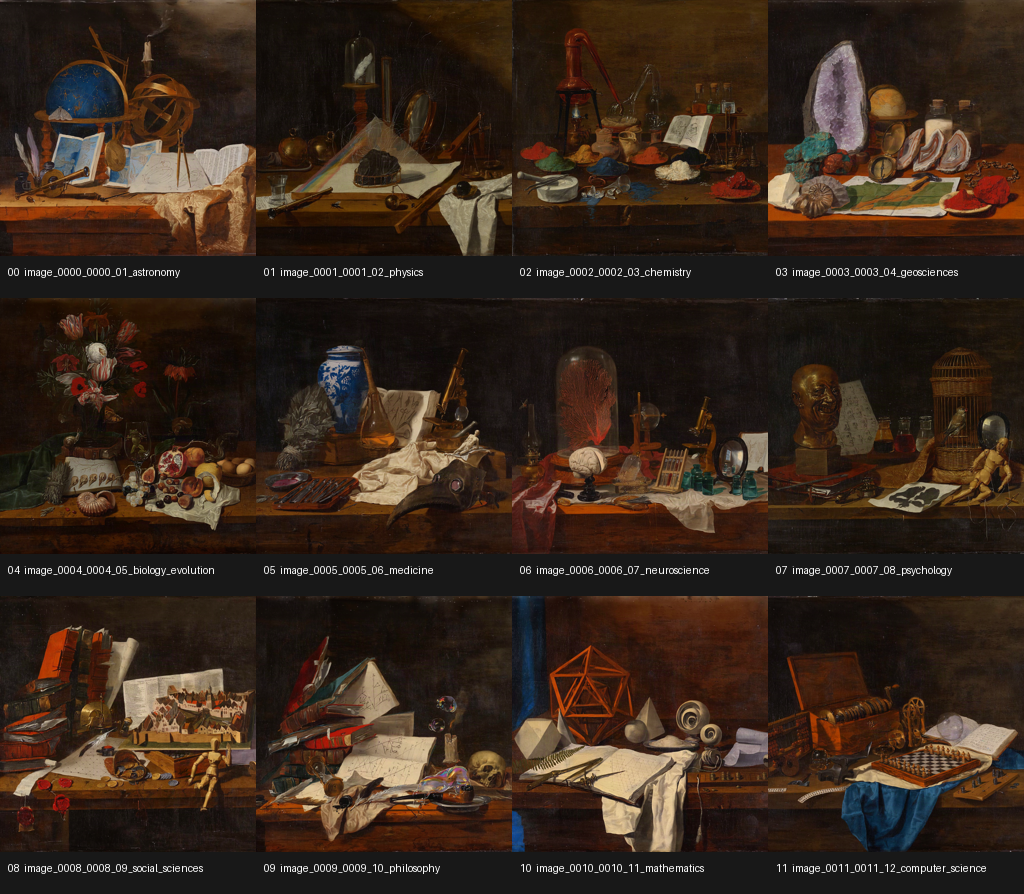


ANCHOR 00: image_0000_0000_01_astronomy
image: /content/drive/MyDrive/FluxFlowMorphArt/manual_bases/manual_base_oil_sciences_ideogram_1/0000_01_astronomy.png
saved prompt: none (image-only source)

ANCHOR 01: image_0001_0001_02_physics
image: /content/drive/MyDrive/FluxFlowMorphArt/manual_bases/manual_base_oil_sciences_ideogram_1/0001_02_physics.png
saved prompt: none (image-only source)

ANCHOR 02: image_0002_0002_03_chemistry
image: /content/drive/MyDrive/FluxFlowMorphArt/manual_bases/manual_base_oil_sciences_ideogram_1/0002_03_chemistry.png
saved prompt: none (image-only source)

ANCHOR 03: image_0003_0003_04_geosciences
image: /content/drive/MyDrive/FluxFlowMorphArt/manual_bases/manual_base_oil_sciences_ideogram_1/0003_04_geosciences.png
saved prompt: none (image-only source)

ANCHOR 04: image_0004_0004_05_biology_evolution
image: /content/drive/MyDrive/FluxFlowMorphArt/manual_bases/manual_base_oil_sciences_ideogram_1/0004_05_biology_evolution.png
saved prompt: none (image-only so

In [ ]:
import re
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Markdown, display

NOTEBOOK_ANCHOR_IMAGE_SUFFIXES = {
    ".bmp", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"
}

def notebook_natural_image_key(path, root):
    relative = path.relative_to(root).as_posix()
    return (
        tuple(
            (0, int(token)) if token.isdigit() else (1, token.casefold())
            for token in re.split(r"(\d+)", relative)
            if token
        ),
        relative,
    )

def load_h3_anchor_records_portable(source_directory):
    """Keep plain-directory loading independent of the checked-out package revision."""

    source_directory = Path(source_directory).expanduser()
    if not source_directory.is_dir():
        raise FileNotFoundError(f"Source directory does not exist: {source_directory}")
    manifest_path = source_directory / "metadata" / "base_manifest.json"
    if manifest_path.is_file():
        return load_h3_anchor_records(source_directory)

    image_paths = sorted(
        (
            path
            for path in source_directory.rglob("*")
            if path.is_file()
            and path.suffix.casefold() in NOTEBOOK_ANCHOR_IMAGE_SUFFIXES
            and not any(
                part.startswith(".")
                for part in path.relative_to(source_directory).parts
            )
        ),
        key=lambda path: notebook_natural_image_key(path, source_directory),
    )
    if len(image_paths) < 2:
        supported = ", ".join(sorted(NOTEBOOK_ANCHOR_IMAGE_SUFFIXES))
        raise ValueError(
            f"Source directory needs at least two supported images; found "
            f"{len(image_paths)} under {source_directory}. Supported extensions: "
            f"{supported}"
        )
    records = []
    for index, image_path in enumerate(image_paths):
        stem_slug = re.sub(
            r"[^a-z0-9]+", "_", image_path.stem.casefold()
        ).strip("_")
        records.append({
            "uid": f"image_{index:04d}_{stem_slug[:48] or 'anchor'}",
            "source_index": index,
            "path": image_path.relative_to(source_directory).as_posix(),
            "resolved_path": str(image_path.resolve()),
            "authored_prompt": "",
            "source_kind": "directory_scan",
        })
    print(
        "No metadata/base_manifest.json found; loaded images directly with the "
        "notebook compatibility scanner."
    )
    return records

BASE_RECORDS = load_h3_anchor_records_portable(SOURCE_RUN)
H3_PAIRS = cyclic_h3_pairs(BASE_RECORDS)
SOURCE_RECORD_MODE = BASE_RECORDS[0].get("source_kind", "base_manifest")

thumbnails = []
thumb_size = 256
for record in BASE_RECORDS:
    with Image.open(record["resolved_path"]) as opened:
        image = opened.convert("RGB")
        image.thumbnail((thumb_size, thumb_size))
        canvas = Image.new("RGB", (thumb_size, thumb_size + 42), "#181818")
        canvas.paste(image, ((thumb_size - image.width) // 2, (thumb_size - image.height) // 2))
    draw = ImageDraw.Draw(canvas)
    draw.text((8, thumb_size + 10), f"{record['source_index']:02d}  {record['uid']}", fill="white")
    thumbnails.append(canvas)

source_sizes = []
for record in BASE_RECORDS:
    with Image.open(record["resolved_path"]) as opened:
        source_sizes.append(tuple(opened.size))
source_aspects = [width / height for width, height in source_sizes]
if max(source_aspects) - min(source_aspects) > 0.001:
    raise ValueError(f"Source anchors do not share one aspect ratio: {source_sizes}")
source_aspect = source_aspects[0]
h3_aspect = H3_WIDTH / H3_HEIGHT
if H3_ENFORCE_SOURCE_ASPECT and abs(source_aspect - h3_aspect) > 0.001:
    raise ValueError(
        f"Source aspect {source_aspect:.5f} does not match H3 canvas "
        f"{H3_WIDTH}x{H3_HEIGHT} ({h3_aspect:.5f}). Set H3_WIDTH/H3_HEIGHT to a "
        "native H3 canvas with the same ratio; refusing to crop or stretch silently."
    )
columns = min(4, len(thumbnails))
rows = (len(thumbnails) + columns - 1) // columns
sheet = Image.new("RGB", (columns * thumb_size, rows * (thumb_size + 42)), "#080808")
for index, thumbnail in enumerate(thumbnails):
    sheet.paste(thumbnail, ((index % columns) * thumb_size, (index // columns) * (thumb_size + 42)))
display(Markdown(
    f"### {len(BASE_RECORDS)} source anchors from `{SOURCE_RUN.name}` "
    f"(`{SOURCE_RECORD_MODE}`)"
))
display(sheet)

for record in BASE_RECORDS:
    print("\n" + "=" * 100)
    print(f"ANCHOR {record['source_index']:02d}: {record['uid']}")
    print("image:", record["resolved_path"])
    authored_prompt = record.get("authored_prompt", "").strip()
    print("saved prompt:" if authored_prompt else "saved prompt: none (image-only source)")
    if authored_prompt:
        print(authored_prompt)
print("\nCyclic pair order:")
for pair in H3_PAIRS:
    print(f"  {pair['index']:02d}: {pair['left']['uid']} -> {pair['right']['uid']}")
print({
    "source_record_mode": SOURCE_RECORD_MODE,
    "source_sizes": sorted(set(source_sizes)),
    "h3_canvas": (H3_WIDTH, H3_HEIGHT),
})


## 6. Build, cache, and print one H3 prompt per pair

In the default `openai_per_pair` mode, GPT always sees both actual endpoint images. Saved
prompts are included as optional semantic context only when present, so a plain image directory
follows the same image-grounded path without placeholder metadata. GPT writes an explicit
screen-position correspondence map and a spatially distributed chronological motion path. Exact
`<Picture 1>` / `<Picture 2>` tags are kept from the OpenAI request through the MiniMax prompt. The editable
`H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS` in the
settings cell follows MiniMax's official FL2VA sequence: exact first-frame state, concurrent
changes across separated regions, optional opaque blending of backgrounds and broad color
fields, progressively narrowing differences, and exact last-frame state.
Fixed code rejects incomplete sentences and incomplete API responses, adds the official
alignment header and three-field H3 format, then counts the final prompt with ComfyUI's
conservative UTF-8 byte ceiling. Qwen's byte-level BPE cannot produce more text tokens
than input bytes, so 8,192 bytes plus the 8,192-token visual reserve stays below 16,384
worst-case tokens versus the encoder's 262,144-token context. This avoids importing the
ComfyUI/Transformers stack into the notebook kernel. The writer instructions, every
correspondence map, prompt byte count, and
every final transition prompt are printed.
The FLUX-only `RIJKSOIL` LoRA token is never sent to H3.


In [ ]:
import base64
import hashlib
import io
import random
from pydantic import BaseModel, Field
from flowmorph_klein.h3_workflow import validate_h3_prompt_byte_budget

def h3_prompt_utf8_bytes(prompt):
    return validate_h3_prompt_byte_budget(
        prompt,
        max_utf8_bytes=H3_PROMPT_MAX_UTF8_BYTES,
        model_context_tokens=H3_TEXT_ENCODER_CONTEXT_TOKENS,
        reserved_condition_tokens=H3_IMAGE_CONDITIONING_TOKEN_RESERVE,
    )

def bounded_backoff_seconds(
    failure_number,
    *,
    initial_seconds,
    maximum_seconds,
    jitter_fraction,
    minimum_seconds=0.0,
):
    base = min(
        float(maximum_seconds),
        float(initial_seconds) * (2 ** max(0, int(failure_number) - 1)),
    )
    jitter = random.uniform(0.0, max(0.0, base * float(jitter_fraction)))
    return max(float(minimum_seconds), base) + jitter

def openai_error_code(error):
    body = getattr(error, "body", None)
    if isinstance(body, dict):
        nested = body.get("error", body)
        if isinstance(nested, dict):
            return str(nested.get("code") or "").strip().lower()
    return ""

def openai_retry_after_seconds(error):
    response = getattr(error, "response", None)
    headers = getattr(response, "headers", None)
    if headers is None:
        return 0.0
    try:
        return max(0.0, float(headers.get("retry-after", 0.0)))
    except (TypeError, ValueError):
        return 0.0

def openai_call_with_backoff(label, operation):
    non_retryable_codes = {
        "billing_hard_limit_reached",
        "credit_balance_exhausted",
        "insufficient_quota",
        "organization_spend_limit_exceeded",
        "organization_usage_limit_exceeded",
        "project_spend_limit_exceeded",
    }
    for transport_attempt in range(1, OPENAI_REQUEST_MAX_ATTEMPTS + 1):
        try:
            return operation()
        except OPENAI_TRANSIENT_ERRORS as error:
            if openai_error_code(error) in non_retryable_codes:
                raise
            if transport_attempt >= OPENAI_REQUEST_MAX_ATTEMPTS:
                raise
            delay = bounded_backoff_seconds(
                transport_attempt,
                initial_seconds=OPENAI_RETRY_INITIAL_SECONDS,
                maximum_seconds=OPENAI_RETRY_MAX_SECONDS,
                jitter_fraction=OPENAI_RETRY_JITTER_FRACTION,
                minimum_seconds=openai_retry_after_seconds(error),
            )
            print(
                f"{label}: transient OpenAI failure on transport attempt "
                f"{transport_attempt}/{OPENAI_REQUEST_MAX_ATTEMPTS}: {error}. "
                f"Retrying in {delay:.1f}s."
            )
            time.sleep(delay)

class H3ObjectCorrespondence(BaseModel):
    source_form_and_region: str = Field(min_length=15, max_length=240)
    target_form_and_region: str = Field(min_length=15, max_length=240)
    continuous_path: str = Field(min_length=25, max_length=500)

class H3MotionProposal(BaseModel):
    object_correspondences: list[H3ObjectCorrespondence] = Field(
        min_length=4, max_length=10
    )
    # Length is app-validated after generation. A schema-level minLength masks the
    # closing quote until the boundary and can make constrained decoding stop mid-clause.
    integrated_multimodal_description: str

def validate_openai_motion_proposal(proposal):
    description = proposal.integrated_multimodal_description.strip()
    if len(description) < OPENAI_H3_DESCRIPTION_MIN_CHARS:
        raise ValueError(
            f"OpenAI H3 description has {len(description)} characters; expand it to "
            f"at least {OPENAI_H3_DESCRIPTION_MIN_CHARS} and finish every sentence"
        )
    if len(description) > OPENAI_H3_DESCRIPTION_MAX_CHARS:
        raise ValueError(
            f"OpenAI H3 description has {len(description)} characters; compact it to "
            f"at most {OPENAI_H3_DESCRIPTION_MAX_CHARS}"
        )
    if not re.search(r'(?:[.!?]|\u2026)[\)\]"\u201d\u2019\']*$', description):
        raise ValueError("OpenAI H3 description ended mid-sentence")
    required = ("[Shot 1]", "<Picture 1>", "<Picture 2>", "Static Shot")
    missing = [item for item in required if item not in description]
    if missing:
        raise ValueError(f"OpenAI H3 description is missing required FL2VA anchors: {missing}")
    if not description.lower().startswith("[shot 1]") or description.lower().count("[shot 1]") != 1:
        raise ValueError("OpenAI H3 description must contain exactly one opening [Shot 1]")
    forbidden_structure = (
        "[Shot 2]",
        "integrated_multimodal_description:",
        "overall_soundscape:",
        "non_diegetic_music:",
    )
    leaked_structure = [
        item for item in forbidden_structure if item.lower() in description.lower()
    ]
    if leaked_structure:
        raise ValueError(f"OpenAI H3 description leaked fixed prompt structure: {leaked_structure}")
    proposal_text = " ".join(
        [description]
        + [
            " ".join((item.source_form_and_region, item.target_form_and_region, item.continuous_path))
            for item in proposal.object_correspondences
        ]
    )
    if "RIJKSOIL" in proposal_text.upper():
        raise ValueError("OpenAI H3 proposal leaked the upstream FLUX LoRA token")
    named_effects = [
        term
        for term in H3_DISALLOWED_GENERATED_TRANSITION_TERMS
        if term.lower() in description.lower()
    ]
    if named_effects:
        raise ValueError(
            f"OpenAI H3 description named disallowed transition effects: {named_effects}"
        )

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def image_data_url(path):
    with Image.open(path) as opened:
        image = opened.convert("RGB")
        image.thumbnail((VISION_IMAGE_MAX_SIDE, VISION_IMAGE_MAX_SIDE))
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG", quality=VISION_JPEG_QUALITY, optimize=True)
    return "data:image/jpeg;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")

def append_optional_prompt_context(content, picture_label, record):
    clean_prompt = strip_h3_source_only_tokens(record.get("authored_prompt", "")).strip()
    if clean_prompt:
        content.append({
            "type": "input_text",
            "text": (
                f"{picture_label} optional authored image prompt (semantic context only):\n"
                + clean_prompt
            ),
        })

def openai_motion_for_pair(pair):
    user_content = [
        {
            "type": "input_text",
            "text": (
                "Create the positive object-correspondence plan and one production-ready "
                "FL2VA integrated multimodal description for this pair. "
                f"The target duration is exactly {H3_DURATION_SECONDS:.2f} seconds. "
                "Some endpoints have no authored prompt; absent context blocks are "
                "intentional, so infer the visual plan from the images themselves."
            ),
        },
        {"type": "input_text", "text": "<Picture 1> — exact first frame:"},
        {
            "type": "input_image",
            "image_url": image_data_url(pair["left"]["resolved_path"]),
            "detail": OPENAI_IMAGE_DETAIL,
        },
    ]
    append_optional_prompt_context(user_content, "<Picture 1>", pair["left"])
    user_content.extend([
        {"type": "input_text", "text": "<Picture 2> — exact last frame:"},
        {
            "type": "input_image",
            "image_url": image_data_url(pair["right"]["resolved_path"]),
            "detail": OPENAI_IMAGE_DETAIL,
        },
    ])
    append_optional_prompt_context(user_content, "<Picture 2>", pair["right"])
    last_error = None
    for attempt in range(1, OPENAI_MAX_ATTEMPTS + 1):
        try:
            attempt_content = list(user_content)
            if attempt > 1:
                attempt_content.append({
                    "type": "input_text",
                    "text": (
                        f"The previous draft was rejected for this exact reason: {last_error}. "
                        "Return a corrected, complete, compact JSON proposal now: 4-10 "
                        "grouped correspondences, an integrated description aiming for "
                        "1,400-1,800 characters and never exceeding 2,400, and a fully "
                        "punctuated final sentence. Use exact <Picture 1>/<Picture 2> tags "
                        "and distributed concurrent changes across left, center, and right. "
                        "When supported by the endpoints, describe opaque blending and "
                        "movement of backgrounds or broad color, shadow, and texture fields. "
                        "Finish naturally well before the hard ceiling; do not stop at a "
                        "character boundary."
                    ),
                })
            response = openai_call_with_backoff(
                f"OpenAI prompt pair {pair['index']:02d}",
                lambda: OPENAI_CLIENT.responses.parse(
                    model=OPENAI_MODEL,
                    reasoning={"effort": OPENAI_REASONING_EFFORT},
                    max_output_tokens=OPENAI_MAX_OUTPUT_TOKENS,
                    input=[
                        {
                            "role": "system",
                            "content": H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS,
                        },
                        {"role": "user", "content": attempt_content},
                    ],
                    text_format=H3MotionProposal,
                ),
            )
            usage = getattr(response, "usage", None)
            output_details = getattr(usage, "output_tokens_details", None)
            print({
                "openai_pair": pair["index"],
                "attempt": attempt,
                "status": response.status,
                "reasoning_effort": OPENAI_REASONING_EFFORT,
                "max_output_tokens": OPENAI_MAX_OUTPUT_TOKENS,
                "input_tokens": getattr(usage, "input_tokens", None),
                "output_tokens_including_reasoning": getattr(usage, "output_tokens", None),
                "reasoning_tokens": getattr(output_details, "reasoning_tokens", None),
            })
            if response.status != "completed":
                reason = getattr(getattr(response, "incomplete_details", None), "reason", None)
                raise RuntimeError(
                    f"OpenAI response status was {response.status!r}; incomplete reason={reason!r}"
                )
            proposal = response.output_parsed
            if proposal is None:
                raise RuntimeError("OpenAI returned no parsed motion proposal")
            description = proposal.integrated_multimodal_description.strip()
            print({
                "openai_pair": pair["index"],
                "attempt": attempt,
                "description_characters": len(description),
                "description_tail": description[-180:],
            })
            validate_openai_motion_proposal(proposal)
            return proposal, response.id
        except Exception as error:
            last_error = error
            print(f"OpenAI pair {pair['index']:02d} attempt {attempt} failed: {error}")
            if attempt < OPENAI_MAX_ATTEMPTS:
                delay = bounded_backoff_seconds(
                    attempt,
                    initial_seconds=OPENAI_RETRY_INITIAL_SECONDS,
                    maximum_seconds=OPENAI_RETRY_MAX_SECONDS,
                    jitter_fraction=OPENAI_RETRY_JITTER_FRACTION,
                )
                print(f"Retrying corrected prompt in {delay:.1f}s.")
                time.sleep(delay)
    raise RuntimeError(f"OpenAI prompt generation failed: {last_error}")

print("OPENAI H3 PROMPT-WRITER INSTRUCTIONS (editable in the settings cell):")
print(H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS)

PAIR_PROMPT_PLANS = {}
openai_prompts_since_pause = 0
for pair_position, pair in enumerate(H3_PAIRS):
    prompt_path = RUN_DIRECTORY / "prompts" / f"{pair['index']:04d}_{pair['left']['uid']}_to_{pair['right']['uid']}.json"
    prompt_basis = {
        "mode": H3_PROMPT_MODE,
        "openai_model": OPENAI_MODEL if H3_PROMPT_MODE == "openai_per_pair" else None,
        "prompt_guide_version": H3_OPENAI_PROMPT_GUIDE_VERSION,
        "prompt_writer_instructions": H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS,
        "disallowed_generated_terms": H3_DISALLOWED_GENERATED_TRANSITION_TERMS,
        "structured_output_schema": "compact-correspondences+distributed-blending-description-v8",
        "openai_max_output_tokens": OPENAI_MAX_OUTPUT_TOKENS,
        "openai_reasoning_effort": OPENAI_REASONING_EFFORT,
        "description_min_chars": OPENAI_H3_DESCRIPTION_MIN_CHARS,
        "description_max_chars": OPENAI_H3_DESCRIPTION_MAX_CHARS,
        "h3_prompt_max_utf8_bytes": H3_PROMPT_MAX_UTF8_BYTES,
        "h3_text_encoder_context_tokens": H3_TEXT_ENCODER_CONTEXT_TOKENS,
        "h3_image_conditioning_token_reserve": H3_IMAGE_CONDITIONING_TOKEN_RESERVE,
        "left_sha256": sha256_file(pair["left"]["resolved_path"]),
        "right_sha256": sha256_file(pair["right"]["resolved_path"]),
        "left_prompt": pair["left"]["authored_prompt"],
        "right_prompt": pair["right"]["authored_prompt"],
        "base_motion_prompt": H3_BASE_MOTION_PROMPT,
        "duration_seconds": H3_DURATION_SECONDS,
        "include_endpoint_prompts": H3_INCLUDE_ENDPOINT_PROMPTS_IN_TEMPLATE,
        "workflow_patch_version": H3_WORKFLOW_PATCH_VERSION,
    }
    fingerprint = stable_h3_fingerprint(prompt_basis)
    cached = None
    if prompt_path.is_file():
        try:
            candidate = json.loads(prompt_path.read_text(encoding="utf-8"))
            if candidate.get("fingerprint") == fingerprint:
                cached = candidate
        except (OSError, json.JSONDecodeError):
            pass
    if cached is not None:
        plan = cached
        plan_source = "cached"
    elif H3_PROMPT_MODE == "template":
        h3_prompt = build_default_h3_prompt(
            duration_seconds=H3_DURATION_SECONDS,
            motion_directive=H3_BASE_MOTION_PROMPT,
        )
        if H3_INCLUDE_ENDPOINT_PROMPTS_IN_TEMPLATE:
            endpoint_context = []
            for picture_label, record in (
                ("<Picture 1>", pair["left"]),
                ("<Picture 2>", pair["right"]),
            ):
                clean_prompt = strip_h3_source_only_tokens(
                    record.get("authored_prompt", "")
                ).strip()
                if clean_prompt:
                    endpoint_context.append(
                        f"Authored visual intent for {picture_label}: {clean_prompt}"
                    )
            if endpoint_context:
                h3_prompt += "\n\n" + "\n".join(endpoint_context)
        plan = {
            "fingerprint": fingerprint,
            "pair_id": pair["pair_id"],
            "mode": H3_PROMPT_MODE,
            "h3_prompt": h3_prompt,
            "object_correspondences": None,
            "openai_response_id": None,
            "basis": prompt_basis,
        }
        plan_source = "generated_template"
    else:
        proposal, response_id = openai_motion_for_pair(pair)
        plan = {
            "fingerprint": fingerprint,
            "pair_id": pair["pair_id"],
            "mode": H3_PROMPT_MODE,
            "h3_prompt": wrap_openai_h3_motion(
                proposal.integrated_multimodal_description,
                duration_seconds=H3_DURATION_SECONDS,
            ),
            "object_correspondences": [
                item.model_dump(mode="json") for item in proposal.object_correspondences
            ],
            "openai_response_id": response_id,
            "basis": prompt_basis,
        }
        plan_source = "generated_openai"
        openai_prompts_since_pause += 1
    prompt_byte_count = h3_prompt_utf8_bytes(plan["h3_prompt"])
    recorded_byte_count = plan.get("h3_prompt_utf8_bytes")
    if recorded_byte_count not in (None, prompt_byte_count):
        raise RuntimeError("Cached H3 prompt byte count no longer matches its prompt")
    plan["h3_prompt_utf8_bytes"] = prompt_byte_count
    prompt_path.write_text(
        json.dumps(plan, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )
    PAIR_PROMPT_PLANS[pair["index"]] = plan
    print("\n" + "=" * 110)
    print(
        f"PAIR {pair['index']:02d}: {pair['left']['uid']} -> {pair['right']['uid']} "
        f"[{plan_source}]"
    )
    print(
        "LEFT AUTHORED PROMPT:\n"
        + (pair["left"]["authored_prompt"] or "[none — image-only source]")
    )
    print(
        "RIGHT AUTHORED PROMPT:\n"
        + (pair["right"]["authored_prompt"] or "[none — image-only source]")
    )
    if plan.get("object_correspondences"):
        print("POSITIVE OBJECT CORRESPONDENCE MAP:")
        for mapping_index, mapping in enumerate(plan["object_correspondences"], start=1):
            print(f"  {mapping_index:02d}. SOURCE: {mapping['source_form_and_region']}")
            print(f"      TARGET: {mapping['target_form_and_region']}")
            print(f"      PATH:   {mapping['continuous_path']}")
    print(
        f"H3 PROMPT UTF-8 BYTES: {prompt_byte_count} / "
        f"{H3_PROMPT_MAX_UTF8_BYTES} operational maximum "
        f"(worst-case text tokens <= {prompt_byte_count})"
    )
    print("GENERATED TRANSITION PROMPT SENT TO LOCAL H3:\n" + plan["h3_prompt"])
    if (
        openai_prompts_since_pause >= OPENAI_PROMPT_BATCH_SIZE
        and pair_position + 1 < len(H3_PAIRS)
    ):
        print(
            f"Completed an OpenAI prompt batch of {openai_prompts_since_pause}; "
            f"pausing {OPENAI_PROMPT_BATCH_PAUSE_SECONDS:.1f}s."
        )
        time.sleep(OPENAI_PROMPT_BATCH_PAUSE_SECONDS)
        openai_prompts_since_pause = 0


OPENAI H3 PROMPT-WRITER INSTRUCTIONS (editable in the settings cell):
You write a structured motion plan for MiniMax H3-Base-FL2VA using two endpoint images.
Inspect <Picture 1> and <Picture 2> as the visual ground truth. Optional authored image
prompts may be supplied as semantic context, but they can never override visible composition.
If no authored prompt is supplied for either endpoint, work directly from the images and do
not invent, request, or assume missing source metadata.

Follow MiniMax's official FL2VA method:
- Plan exactly one [Shot 1]. It is a Static Shot with unchanged framing, lens, viewpoint,
  crop, and tabletop horizon. Keep the background spatially registered and the overall
  illumination direction stable, while allowing background appearance and broad color or
  light fields to move and develop toward the endpoint.
- Use this chronology: <Picture 1> state -> observable intermediate changes -> progressively
  narrowing differences -> exact <Picture 2> state.
- Do

## 7. Download the released H3 checkpoints into local ComfyUI storage

This downloads roughly 40 GB once per Colab VM: the pruned INT8 FL2VA transformer,
NVFP4 Qwen3-VL encoder, FP16 video VAE, and audio VAE selected by the official workflow.
Files stay on fast ephemeral storage for inference; clips and metadata go straight to
Drive. The 2K regenerator is deliberately absent because MiniMax has not open-sourced it.


In [ ]:
from huggingface_hub import hf_hub_download

MODEL_FILES = [
    ("diffusion_models/" + H3_DIFFUSION_MODEL, 19.0),
    ("text_encoders/" + H3_TEXT_ENCODER, 14.0),
    ("vae/" + H3_VIDEO_VAE, 4.5),
    ("vae/" + H3_AUDIO_VAE, 0.5),
]
free_disk_gib = shutil.disk_usage("/content").free / 1024**3
existing_gib = 0.0
for relative_name, _ in MODEL_FILES:
    candidate = Path(COMFYUI_ROOT) / "models" / relative_name
    if candidate.is_file():
        existing_gib += candidate.stat().st_size / 1024**3
required_remaining_gib = max(0.0, 40.0 - existing_gib)
if free_disk_gib < required_remaining_gib + 20.0:
    raise RuntimeError(
        f"Only {free_disk_gib:.1f} GiB local disk is free; the remaining H3 download "
        f"plus working headroom needs about {required_remaining_gib + 20.0:.1f} GiB."
    )
print({
    "free_local_disk_gib": round(free_disk_gib, 2),
    "already_present_h3_gib": round(existing_gib, 2),
    "estimated_remaining_h3_gib": round(required_remaining_gib, 2),
})

resolved_model_paths = {}
for relative_name, minimum_gib in MODEL_FILES:
    print("Resolving", relative_name, flush=True)
    resolved = Path(hf_hub_download(
        repo_id=H3_MODEL_REPOSITORY,
        filename=relative_name,
        revision=H3_MODEL_REVISION,
        local_dir=Path(COMFYUI_ROOT) / "models",
        cache_dir=HF_CACHE_DIR,
    ))
    if not resolved.is_file() or resolved.stat().st_size / 1024**3 < minimum_gib:
        raise RuntimeError(f"H3 model file is incomplete: {resolved}")
    resolved_model_paths[relative_name] = str(resolved)
print("All released H3 checkpoints are complete:")
for relative_name, path in resolved_model_paths.items():
    print(f"  {relative_name}: {Path(path).stat().st_size / 1024**3:.2f} GiB")


{'free_local_disk_gib': 24.04, 'already_present_h3_gib': 39.55, 'estimated_remaining_h3_gib': 0.45}
Resolving diffusion_models/minimax_h3_fl2va_pruned_int8_convrot.safetensors
Resolving text_encoders/qwen3vl_32b_minimax_h3_nvfp4_awq.safetensors
Resolving vae/minimax_h3_video_vae_fp16.safetensors
Resolving vae/minimax_h3_audio_vae_fp32.safetensors
All released H3 checkpoints are complete:
  diffusion_models/minimax_h3_fl2va_pruned_int8_convrot.safetensors: 19.53 GiB
  text_encoders/qwen3vl_32b_minimax_h3_nvfp4_awq.safetensors: 14.61 GiB
  vae/minimax_h3_video_vae_fp16.safetensors: 4.85 GiB
  vae/minimax_h3_audio_vae_fp32.safetensors: 0.56 GiB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


## 8. Start one persistent, local-only ComfyUI H3 server

The server binds only to `127.0.0.1`; API/partner nodes are disabled. L4-class cards use
low-VRAM offload. A100 and larger use ComfyUI's default dynamic smart-memory policy.
The same process serves every pair so model components can remain cached between jobs.


In [18]:
import threading
import urllib.error

H3_SERVER_URL = f"http://127.0.0.1:{H3_COMFY_PORT}"
COMFY_LOG_PATH = Path(LOCAL_ASSET_ROOT) / "comfy_h3_server.log"

def comfy_server_ready():
    try:
        with urllib.request.urlopen(H3_SERVER_URL + "/system_stats", timeout=2) as response:
            return response.status == 200
    except (OSError, urllib.error.URLError):
        return False

H3_SERVER_START_LOCK = globals().get(
    "H3_SERVER_START_LOCK", threading.Lock()
)

def ensure_h3_server_running():
    global H3_COMFY_PROCESS, COMFY_LOG_HANDLE
    with H3_SERVER_START_LOCK:
        H3_COMFY_PROCESS = globals().get("H3_COMFY_PROCESS")
        if comfy_server_ready():
            server_source = "already_running"
        else:
            if (
                H3_COMFY_PROCESS is not None
                and H3_COMFY_PROCESS.poll() is None
            ):
                startup_grace_deadline = time.time() + 60
                while (
                    time.time() < startup_grace_deadline
                    and not comfy_server_ready()
                    and H3_COMFY_PROCESS.poll() is None
                ):
                    time.sleep(2)
            if not comfy_server_ready():
                if (
                    H3_COMFY_PROCESS is not None
                    and H3_COMFY_PROCESS.poll() is None
                ):
                    tail = COMFY_LOG_PATH.read_text(
                        encoding="utf-8", errors="replace"
                    )[-10000:]
                    raise RuntimeError(
                        "ComfyUI process is alive but its local server is not ready.\n"
                        + tail
                    )
                launch = [
                    sys.executable, str(Path(COMFYUI_ROOT) / "main.py"),
                    "--listen", "127.0.0.1", "--port", str(H3_COMFY_PORT),
                    "--disable-api-nodes", "--disable-metadata",
                    "--preview-method", "none",
                    "--reserve-vram", "3" if gpu_vram_gib >= 35 else "2",
                ]
                if gpu_vram_gib < 35:
                    launch.append("--lowvram")
                environment = dict(os.environ)
                environment["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
                COMFY_LOG_HANDLE = COMFY_LOG_PATH.open("w", encoding="utf-8")
                H3_COMFY_PROCESS = subprocess.Popen(
                    launch,
                    cwd=COMFYUI_ROOT,
                    stdout=COMFY_LOG_HANDLE,
                    stderr=subprocess.STDOUT,
                    env=environment,
                    text=True,
                )
                deadline = time.time() + 600
                while time.time() < deadline and not comfy_server_ready():
                    if H3_COMFY_PROCESS.poll() is not None:
                        tail = COMFY_LOG_PATH.read_text(
                            encoding="utf-8", errors="replace"
                        )[-10000:]
                        raise RuntimeError("ComfyUI exited during startup:\n" + tail)
                    time.sleep(3)
                if not comfy_server_ready():
                    raise TimeoutError(
                        "ComfyUI did not become ready within ten minutes"
                    )
                server_source = "restarted_automatically"
        state = {
            "server": H3_SERVER_URL,
            "source": server_source,
            "pid": getattr(H3_COMFY_PROCESS, "pid", None),
            "log": str(COMFY_LOG_PATH),
            "memory_mode": (
                "lowvram" if gpu_vram_gib < 35 else "dynamic_default"
            ),
        }
        print(state)
        return state

H3_SERVER_STATE = ensure_h3_server_running()


{'server': 'http://127.0.0.1:8188', 'source': 'restarted_automatically', 'pid': 44458, 'log': '/content/minimax_h3_interpolation/comfy_h3_server.log', 'memory_mode': 'dynamic_default'}


In [19]:
# H3_BASE_SEED = int(json.loads(
#     (Path(RUN_DIRECTORY) / "metadata" / "run_seed.json").read_text()
# )["h3_base_seed"])

# H3_REJECTED_VIDEO_SUBDIRECTORY = "rejected_videos"

## 9. Render one test pair, then the complete resumable cyclic set

Each job copies two source images to local ComfyUI input storage, patches the pinned
official UI workflow, converts it to the API graph client-side, and executes locally.
Pair manifests include all inputs and a fingerprint; a disconnected rerun reuses only
clips whose exact source images, prompts, checkpoints, seed, size, and duration match.
Ordinary transition requests are submitted through a bounded parallel pool; each pair has
independent exponential backoff and resumable state. ComfyUI schedules the actual work on
the available GPU. After every clip, OpenAI compares 1-3 ordered interior frames with both
endpoints and two known-bad visual calibration examples. Only a high-confidence catastrophic
verdict triggers a new-seed retry. Rejected MP4s are retained in `rejected_videos`;
sampled frames and judgment evidence remain in `diagnostics`.


In [20]:
import glob
import imageio_ffmpeg
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Literal

H3_TEMPLATE = json.loads(template_path.read_text(encoding="utf-8"))
COMFY_INPUT = Path(COMFYUI_ROOT) / "input"
COMFY_OUTPUT = Path(COMFYUI_ROOT) / "output"
COMFY_INPUT.mkdir(parents=True, exist_ok=True)
COMFY_OUTPUT.mkdir(parents=True, exist_ok=True)
H3_FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()

class H3QualityJudgment(BaseModel):
    verdict: Literal["pass", "retry"]
    catastrophic_failure_types: list[Literal[
        "none",
        "dominant_blank_or_flat_field",
        "disconnected_collage_or_cutouts",
        "frame_wide_wipe_or_split",
        "major_content_loss_or_unrelated_scene",
        "severe_corruption",
    ]] = Field(min_length=1, max_length=3)
    confidence: float = Field(ge=0.0, le=1.0)
    reason: str = Field(min_length=5, max_length=400)

def safe_name(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("._") or "pair"

def resolve_h3_base_seed_for_render():
    global H3_BASE_SEED
    if H3_BASE_SEED is None:
        active_run_directory = globals().get("RUN_DIRECTORY")
        if active_run_directory is None:
            raise RuntimeError(
                "H3_BASE_SEED is unset and no active run exists; rerun the Drive/run cell."
            )
        persisted_seed_path = (
            Path(active_run_directory) / "metadata" / "run_seed.json"
        )
        if not persisted_seed_path.is_file():
            raise RuntimeError(
                "H3_BASE_SEED is unset and the active run has no persisted seed: "
                f"{persisted_seed_path}. Rerun the Drive/run cell."
            )
        H3_BASE_SEED = int(json.loads(
            persisted_seed_path.read_text(encoding="utf-8")
        )["h3_base_seed"])
        print(
            "Recovered H3_BASE_SEED from the active run after an out-of-order "
            "settings-cell rerun."
        )
    resolved_seed = int(H3_BASE_SEED)
    if not 0 <= resolved_seed < 2**63:
        raise ValueError("H3_BASE_SEED is outside [0, 2**63)")
    return resolved_seed

def h3_job_payload(pair, render_attempt=1):
    prompt_plan = PAIR_PROMPT_PLANS[pair["index"]]
    prompt_byte_count = h3_prompt_utf8_bytes(prompt_plan["h3_prompt"])
    if prompt_plan.get("h3_prompt_utf8_bytes") != prompt_byte_count:
        raise RuntimeError("H3 prompt changed after its UTF-8 byte audit")
    retry_offset = (max(1, int(render_attempt)) - 1) * H3_RETRY_SEED_STRIDE
    base_seed = resolve_h3_base_seed_for_render()
    return {
        "pair_id": pair["pair_id"],
        "left_uid": pair["left"]["uid"],
        "right_uid": pair["right"]["uid"],
        "left_sha256": sha256_file(pair["left"]["resolved_path"]),
        "right_sha256": sha256_file(pair["right"]["resolved_path"]),
        "prompt_fingerprint": prompt_plan["fingerprint"],
        "h3_prompt": prompt_plan["h3_prompt"],
        "h3_prompt_utf8_bytes": prompt_byte_count,
        "h3_prompt_max_utf8_bytes": H3_PROMPT_MAX_UTF8_BYTES,
        "seed": (base_seed + pair["index"] + retry_offset) % (2**63 - 1),
        "width": H3_WIDTH,
        "height": H3_HEIGHT,
        "duration_seconds": H3_DURATION_SECONDS,
        "frame_count": H3_FRAME_COUNT,
        "fps": H3_FPS,
        "job_timeout_seconds": H3_JOB_TIMEOUT_SECONDS,
        "workflow_patch_version": H3_WORKFLOW_PATCH_VERSION,
        "comfyui_revision": COMFYUI_REVISION,
        "template_revision": H3_TEMPLATE_REVISION,
        "model_repository": H3_MODEL_REPOSITORY,
        "model_revision": H3_MODEL_REVISION,
        "diffusion_model": H3_DIFFUSION_MODEL,
        "text_encoder": H3_TEXT_ENCODER,
        "video_vae": H3_VIDEO_VAE,
        "audio_vae": H3_AUDIO_VAE,
    }

def stream_command(command):
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    output_lines = []
    assert process.stdout is not None
    for line in process.stdout:
        output_lines.append(line)
        print(line, end="", flush=True)
    return process.wait(), "".join(output_lines)

def render_h3_attempt(pair, render_attempt, clip_path, pair_slug):
    ensure_h3_server_running()
    payload = h3_job_payload(pair, render_attempt=render_attempt)
    first_name = f"h3_{RUN_DIRECTORY.name}_{pair['index']:04d}_first.png"
    last_name = f"h3_{RUN_DIRECTORY.name}_{pair['index']:04d}_last.png"
    for source, name in (
        (pair["left"]["resolved_path"], first_name),
        (pair["right"]["resolved_path"], last_name),
    ):
        with Image.open(source) as opened:
            opened.convert("RGB").save(COMFY_INPUT / name, format="PNG", compress_level=4)

    output_prefix = (
        f"h3_{RUN_DIRECTORY.name}/{pair['index']:04d}_{pair_slug}"
        f"_attempt_{render_attempt:02d}"
    )
    workflow = patch_h3_ui_workflow(
        H3_TEMPLATE,
        first_image=first_name,
        last_image=last_name,
        prompt=payload["h3_prompt"],
        width=H3_WIDTH,
        height=H3_HEIGHT,
        duration_seconds=H3_DURATION_SECONDS,
        seed=payload["seed"],
        output_prefix=output_prefix,
        diffusion_model=H3_DIFFUSION_MODEL,
        text_encoder=H3_TEXT_ENCODER,
        video_vae=H3_VIDEO_VAE,
        audio_vae=H3_AUDIO_VAE,
    )
    executable_controls = h3_ui_workflow_controls(workflow)
    forbidden_demo_fragments = ("Vaporwave", "LATENT CONTROLNET", "DIRECTED BY COMFYUI")
    serialized_workflow = json.dumps(workflow, ensure_ascii=False)
    leaked = [fragment for fragment in forbidden_demo_fragments if fragment in serialized_workflow]
    if leaked:
        raise RuntimeError(f"Official H3 demo content survived workflow patching: {leaked}")
    if "RIJKSOIL" in payload["h3_prompt"]:
        raise RuntimeError("Upstream FLUX LoRA token leaked into the MiniMax H3 prompt")
    workflow_path = (
        RUN_DIRECTORY / "workflows" /
        f"pair_{pair['index']:04d}_attempt_{render_attempt:02d}.json"
    )
    workflow_path.write_text(
        json.dumps(workflow, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )
    print("\n" + "=" * 110)
    print(
        f"LOCAL H3 PAIR {pair['index']:02d} ATTEMPT {render_attempt}: "
        f"{pair['left']['uid']} -> {pair['right']['uid']}"
    )
    print("seed:", payload["seed"])
    print("EXECUTABLE H3 CONTROLS:\n" + json.dumps(executable_controls, indent=2, ensure_ascii=False))
    print("prompt:\n" + payload["h3_prompt"])
    command = [
        sys.executable, "-m", "comfy_cli", "--workspace", COMFYUI_ROOT,
        "run", "--workflow", str(workflow_path), "--wait", "--no-notify",
        "--where", "local", "--host", "127.0.0.1", "--port", str(H3_COMFY_PORT),
        "--timeout", str(H3_JOB_TIMEOUT_SECONDS),
    ]
    return_code, command_log = stream_command(command)
    if return_code != 0:
        server_tail = COMFY_LOG_PATH.read_text(encoding="utf-8", errors="replace")[-12000:]
        raise RuntimeError(
            f"H3 pair {pair['index']} failed with exit code {return_code}.\n"
            f"CLI tail:\n{command_log[-8000:]}\nComfyUI tail:\n{server_tail}"
        )
    output_directory = COMFY_OUTPUT / f"h3_{RUN_DIRECTORY.name}"
    candidates = sorted(
        output_directory.glob(
            f"{pair['index']:04d}_{pair_slug}_attempt_{render_attempt:02d}*.mp4"
        ),
        key=lambda path: (path.stat().st_mtime_ns, path.name),
    )
    if not candidates:
        raise RuntimeError(f"ComfyUI completed but no H3 clip matched {output_prefix}")
    shutil.copy2(candidates[-1], clip_path)
    if not clip_path.is_file() or clip_path.stat().st_size == 0:
        raise RuntimeError(f"Persistent H3 clip is empty: {clip_path}")
    return {
        "render_succeeded": True,
        "render_attempt": render_attempt,
        "clip_path": str(clip_path),
        "workflow_path": str(workflow_path),
        "payload": payload,
        "source_comfy_output": str(candidates[-1]),
        "native_audio_kept_in_pair_clip": H3_KEEP_NATIVE_AUDIO_IN_PAIR_CLIPS,
        "reused": False,
    }

def h3_quality_sample_fractions():
    count = int(H3_QUALITY_SAMPLE_FRAME_COUNT)
    return tuple((index + 1) / (count + 1) for index in range(count))

def resolve_h3_quality_negative_examples():
    resolved = []
    cache_directory = Path(LOCAL_ASSET_ROOT) / "h3_quality_examples"
    cache_directory.mkdir(parents=True, exist_ok=True)
    for example_number, configured in enumerate(
        H3_QUALITY_NEGATIVE_EXAMPLES, start=1
    ):
        relative_path = configured["relative_path"]
        expected_sha256 = configured["sha256"]
        repository_path = Path(PROJECT_ROOT) / relative_path
        cache_path = cache_directory / Path(relative_path).name
        valid_path = next((
            candidate for candidate in (repository_path, cache_path)
            if candidate.is_file() and sha256_file(candidate) == expected_sha256
        ), None)
        if valid_path is not None:
            example_path = valid_path
            example_source = (
                "repository_asset"
                if valid_path == repository_path
                else "github_download_cache"
            )
        else:
            temporary_path = cache_path.with_suffix(cache_path.suffix + ".part")
            try:
                urllib.request.urlretrieve(
                    configured["download_url"], temporary_path
                )
            except Exception as error:
                raise RuntimeError(
                    f"Could not download H3 quality example {example_number} from "
                    f"{configured['download_url']}"
                ) from error
            downloaded_sha256 = sha256_file(temporary_path)
            if downloaded_sha256 != expected_sha256:
                temporary_path.unlink(missing_ok=True)
                raise RuntimeError(
                    f"H3 quality example {example_number} failed its SHA-256 check: "
                    f"expected {expected_sha256}, received {downloaded_sha256}"
                )
            temporary_path.replace(cache_path)
            example_path = cache_path
            example_source = "github_download"
            print(
                f"Downloaded H3 quality example {example_number}: "
                f"{configured['download_url']}"
            )
        resolved.append({
            **configured,
            "example_number": example_number,
            "resolved_path": example_path,
            "image_url": image_data_url(example_path),
            "source": example_source,
            "sha256": expected_sha256,
        })
    return resolved

H3_RESOLVED_QUALITY_NEGATIVE_EXAMPLES = (
    resolve_h3_quality_negative_examples()
    if RUN_OPENAI_H3_QUALITY_GATE else []
)

def extract_h3_quality_frames(clip_path, pair, render_attempt):
    fractions = h3_quality_sample_fractions()
    quality_directory = (
        RUN_DIRECTORY / "diagnostics" /
        f"quality_pair_{pair['index']:04d}" /
        f"attempt_{render_attempt:02d}"
    )
    quality_directory.mkdir(parents=True, exist_ok=True)
    frame_paths = []
    for frame_number, fraction in enumerate(fractions, start=1):
        frame_path = quality_directory / f"middle_{frame_number:02d}.png"
        command = [
            H3_FFMPEG, "-y", "-loglevel", "error", "-i", str(clip_path),
            "-ss", f"{H3_DURATION_SECONDS * fraction:.3f}",
            "-map", "0:v:0", "-frames:v", "1", "-an", str(frame_path),
        ]
        completed = subprocess.run(command, capture_output=True, text=True)
        if completed.returncode != 0 or not frame_path.is_file():
            raise RuntimeError(
                f"Could not extract H3 quality frame {frame_number}: "
                f"{completed.stderr[-2000:]}"
            )
        frame_paths.append(frame_path)
    return fractions, frame_paths

def judge_h3_clip(pair, clip_path, render_attempt):
    if not RUN_OPENAI_H3_QUALITY_GATE:
        return {
            "gate_version": H3_QUALITY_GATE_VERSION,
            "enabled": False,
            "effective_verdict": "pass",
            "gate_passed": True,
            "reason": "OpenAI H3 quality gate disabled by settings.",
        }
    fractions, frame_paths = extract_h3_quality_frames(
        clip_path, pair, render_attempt
    )
    negative_examples = H3_RESOLVED_QUALITY_NEGATIVE_EXAMPLES
    quality_basis = {
        "gate_version": H3_QUALITY_GATE_VERSION,
        "instructions": H3_OPENAI_QUALITY_GATE_INSTRUCTIONS,
        "model": OPENAI_MODEL,
        "reasoning_effort": OPENAI_QUALITY_REASONING_EFFORT,
        "image_detail": OPENAI_QUALITY_IMAGE_DETAIL,
        "retry_min_confidence": H3_QUALITY_RETRY_MIN_CONFIDENCE,
        "sample_fractions": fractions,
        "left_sha256": sha256_file(pair["left"]["resolved_path"]),
        "right_sha256": sha256_file(pair["right"]["resolved_path"]),
        "clip_sha256": sha256_file(clip_path),
        "sample_sha256": [sha256_file(path) for path in frame_paths],
        "negative_examples": [{
            "relative_path": example["relative_path"],
            "download_url": example["download_url"],
            "failure_type": example["failure_type"],
            "description": example["description"],
            "source": example["source"],
            "sha256": example["sha256"],
        } for example in negative_examples],
    }
    quality_fingerprint = stable_h3_fingerprint(quality_basis)
    report_path = (
        RUN_DIRECTORY / "metadata" / f"h3_quality_{pair['index']:04d}.json"
    )
    if report_path.is_file():
        try:
            cached = json.loads(report_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            cached = None
        if cached and cached.get("fingerprint") == quality_fingerprint:
            print(
                f"Reusing quality judgment for pair {pair['index']:02d}: "
                f"{cached['effective_verdict']}"
            )
            return {**cached, "cached": True}

    user_content = [{
        "type": "input_text",
        "text": (
            "Calibration section: the following user-supplied images are known RETRY "
            "cases. Learn only each labeled failure pattern, not its subjects, colors, "
            "style, or layout. Do not judge the candidate until the candidate section."
        ),
    }]
    for example in negative_examples:
        user_content.extend([{
            "type": "input_text",
            "text": (
                f"Known RETRY example {example['example_number']} — "
                f"{example['failure_type']}: {example['description']}"
            ),
        }, {
            "type": "input_image",
            "image_url": example["image_url"],
            "detail": OPENAI_QUALITY_IMAGE_DETAIL,
        }])
    user_content.extend([{
        "type": "input_text",
        "text": (
            "Candidate section: judge this ordered H3 transition independently. Return "
            "retry only for an obvious major failure. The endpoint images are references; "
            "judge the interior frames."
        ),
    }, {
        "type": "input_text",
        "text": "<Picture 1> — exact first endpoint:",
    }, {
        "type": "input_image",
        "image_url": image_data_url(pair["left"]["resolved_path"]),
        "detail": OPENAI_QUALITY_IMAGE_DETAIL,
    }])
    for frame_number, (fraction, frame_path) in enumerate(
        zip(fractions, frame_paths), start=1
    ):
        user_content.extend([{
            "type": "input_text",
            "text": (
                f"Interior frame {frame_number}/{len(frame_paths)} "
                f"at {fraction:.0%} of the transition:"
            ),
        }, {
            "type": "input_image",
            "image_url": image_data_url(frame_path),
            "detail": OPENAI_QUALITY_IMAGE_DETAIL,
        }])
    user_content.extend([{
        "type": "input_text",
        "text": "<Picture 2> — exact last endpoint:",
    }, {
        "type": "input_image",
        "image_url": image_data_url(pair["right"]["resolved_path"]),
        "detail": OPENAI_QUALITY_IMAGE_DETAIL,
    }])
    response = openai_call_with_backoff(
        f"OpenAI quality gate pair {pair['index']:02d}",
        lambda: OPENAI_CLIENT.responses.parse(
            model=OPENAI_MODEL,
            reasoning={"effort": OPENAI_QUALITY_REASONING_EFFORT},
            max_output_tokens=OPENAI_QUALITY_MAX_OUTPUT_TOKENS,
            input=[{
                "role": "system",
                "content": H3_OPENAI_QUALITY_GATE_INSTRUCTIONS,
            }, {"role": "user", "content": user_content}],
            text_format=H3QualityJudgment,
        ),
    )
    if response.status != "completed" or response.output_parsed is None:
        reason = getattr(getattr(response, "incomplete_details", None), "reason", None)
        raise RuntimeError(
            f"OpenAI H3 quality judgment was incomplete: "
            f"status={response.status!r}, reason={reason!r}"
        )
    judgment = response.output_parsed
    high_confidence_retry = (
        judgment.verdict == "retry"
        and judgment.confidence >= H3_QUALITY_RETRY_MIN_CONFIDENCE
    )
    report = {
        "fingerprint": quality_fingerprint,
        "basis": quality_basis,
        "gate_version": H3_QUALITY_GATE_VERSION,
        "enabled": True,
        "render_attempt": render_attempt,
        "sample_frame_paths": [str(path) for path in frame_paths],
        "openai_response_id": response.id,
        "model_judgment": judgment.model_dump(mode="json"),
        "effective_verdict": "retry" if high_confidence_retry else "pass",
        "gate_passed": not high_confidence_retry,
        "low_confidence_retry_overridden": (
            judgment.verdict == "retry" and not high_confidence_retry
        ),
        "cached": False,
    }
    report_path.write_text(
        json.dumps(report, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )
    print({
        "quality_pair": pair["index"],
        "render_attempt": render_attempt,
        "model_verdict": judgment.verdict,
        "confidence": judgment.confidence,
        "effective_verdict": report["effective_verdict"],
        "failure_types": judgment.catastrophic_failure_types,
        "reason": judgment.reason,
    })
    return report

def h3_rejected_video_directory():
    subdirectory = globals().get(
        "H3_REJECTED_VIDEO_SUBDIRECTORY", "rejected_videos"
    )
    if not subdirectory or Path(subdirectory).name != subdirectory:
        raise ValueError(
            "H3_REJECTED_VIDEO_SUBDIRECTORY must be one directory name"
        )
    return RUN_DIRECTORY / subdirectory

def archive_rejected_h3_clip(pair, clip_path, render_attempt):
    rejected_directory = h3_rejected_video_directory()
    rejected_directory.mkdir(parents=True, exist_ok=True)
    rejected_path = rejected_directory / (
        f"pair_{pair['index']:04d}_{safe_name(pair['pair_id'])}"
        f"_attempt_{render_attempt:02d}_rejected.mp4"
    )
    shutil.copy2(clip_path, rejected_path)
    print(f"Saved rejected H3 video: {rejected_path}")
    return rejected_path

def render_h3_pair(pair):
    base_payload = h3_job_payload(pair, render_attempt=1)
    fingerprint = stable_h3_fingerprint(base_payload)
    pair_slug = safe_name(pair["pair_id"])
    clip_path = RUN_DIRECTORY / "clips" / f"{pair['index']:04d}_{pair_slug}.mp4"
    manifest_path = RUN_DIRECTORY / "metadata" / f"h3_pair_{pair['index']:04d}.json"
    prior = {}
    if H3_REUSE_EXISTING_CLIPS and manifest_path.is_file():
        try:
            prior = json.loads(manifest_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            prior = {}
    attempt_history = list(prior.get("attempt_history", []))
    prior_attempt = max(1, int(prior.get("render_attempt", 1)))
    reusable_render = (
        H3_REUSE_EXISTING_CLIPS
        and clip_path.is_file()
        and clip_path.stat().st_size > 0
        and prior.get("fingerprint") == fingerprint
        and (prior.get("complete") is True or prior.get("render_succeeded") is True)
    )
    if reusable_render:
        quality = judge_h3_clip(pair, clip_path, prior_attempt)
        if quality["gate_passed"]:
            record = {
                **prior,
                "complete": True,
                "render_succeeded": True,
                "quality_gate": quality,
                "clip_path": str(clip_path),
                "reused": True,
            }
            manifest_path.write_text(
                json.dumps(record, indent=2, ensure_ascii=False) + "\n",
                encoding="utf-8",
            )
            print(f"Reusing quality-approved pair {pair['index']:02d}: {clip_path.name}")
            return record
        rejected_path = archive_rejected_h3_clip(
            pair, clip_path, prior_attempt
        )
        attempt_history.append({
            "render_attempt": prior_attempt,
            "seed": prior.get("payload", {}).get("seed"),
            "result": "quality_rejected_on_resume",
            "rejected_clip_path": str(rejected_path),
            "quality_gate": quality,
        })

    prior_numbers = [
        int(item.get("render_attempt", 0))
        for item in attempt_history
        if isinstance(item, dict)
    ]
    first_render_attempt = max(prior_numbers + ([prior_attempt] if reusable_render else [0])) + 1
    last_error = None
    for attempt_offset in range(H3_MAX_RENDER_ATTEMPTS):
        render_attempt = first_render_attempt + attempt_offset
        try:
            rendered = render_h3_attempt(
                pair, render_attempt, clip_path, pair_slug
            )
        except Exception as error:
            last_error = error
            attempt_history.append({
                "render_attempt": render_attempt,
                "seed": h3_job_payload(pair, render_attempt)["seed"],
                "result": "render_error",
                "error": str(error),
            })
            manifest_path.write_text(json.dumps({
                "complete": False,
                "render_succeeded": False,
                "fingerprint": fingerprint,
                "clip_path": str(clip_path),
                "render_attempt": render_attempt,
                "attempt_history": attempt_history,
            }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
            if attempt_offset + 1 >= H3_MAX_RENDER_ATTEMPTS:
                break
            delay = bounded_backoff_seconds(
                attempt_offset + 1,
                initial_seconds=H3_RENDER_RETRY_INITIAL_SECONDS,
                maximum_seconds=H3_RENDER_RETRY_MAX_SECONDS,
                jitter_fraction=H3_RENDER_RETRY_JITTER_FRACTION,
            )
            print(
                f"H3 pair {pair['index']:02d} render attempt {render_attempt} failed: "
                f"{error}. Retrying in {delay:.1f}s."
            )
            time.sleep(delay)
            continue

        try:
            quality = judge_h3_clip(pair, clip_path, render_attempt)
        except Exception:
            manifest_path.write_text(json.dumps({
                **rendered,
                "complete": False,
                "fingerprint": fingerprint,
                "awaiting_quality_gate": True,
                "attempt_history": attempt_history,
            }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
            raise
        history_entry = {
            "render_attempt": render_attempt,
            "seed": rendered["payload"]["seed"],
            "result": (
                "quality_passed" if quality["gate_passed"] else "quality_rejected"
            ),
            "quality_gate": quality,
        }
        if quality["gate_passed"]:
            attempt_history.append(history_entry)
            record = {
                **rendered,
                "complete": True,
                "fingerprint": fingerprint,
                "quality_gate": quality,
                "attempt_history": attempt_history,
            }
            manifest_path.write_text(
                json.dumps(record, indent=2, ensure_ascii=False) + "\n",
                encoding="utf-8",
            )
            return record

        rejected_path = archive_rejected_h3_clip(
            pair, clip_path, render_attempt
        )
        history_entry["rejected_clip_path"] = str(rejected_path)
        attempt_history.append(history_entry)
        last_error = RuntimeError(
            f"OpenAI quality gate rejected H3 pair {pair['index']:02d} "
            f"attempt {render_attempt}: "
            f"{quality['model_judgment']['reason']}"
        )
        manifest_path.write_text(json.dumps({
            **rendered,
            "complete": False,
            "fingerprint": fingerprint,
            "quality_gate": quality,
            "attempt_history": attempt_history,
        }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
        if attempt_offset + 1 < H3_MAX_RENDER_ATTEMPTS:
            delay = bounded_backoff_seconds(
                attempt_offset + 1,
                initial_seconds=H3_RENDER_RETRY_INITIAL_SECONDS,
                maximum_seconds=H3_RENDER_RETRY_MAX_SECONDS,
                jitter_fraction=H3_RENDER_RETRY_JITTER_FRACTION,
            )
            print(f"{last_error}. Retrying with a new seed in {delay:.1f}s.")
            time.sleep(delay)
    raise RuntimeError(
        f"H3 pair {pair['index']:02d} exhausted {H3_MAX_RENDER_ATTEMPTS} "
        f"attempts in this execution; diagnostics were retained. Last error: "
        f"{last_error}"
    )

def render_h3_pairs_parallel(pairs):
    records = {}
    failures = {}
    worker_count = min(H3_MAX_PARALLEL_TRANSITION_CALLS, len(pairs))
    print(
        f"Submitting {len(pairs)} ordinary H3 transition calls with "
        f"at most {worker_count} concurrent calls."
    )
    with ThreadPoolExecutor(
        max_workers=worker_count,
        thread_name_prefix="h3-transition",
    ) as executor:
        future_to_pair = {
            executor.submit(render_h3_pair, pair): pair for pair in pairs
        }
        for future in as_completed(future_to_pair):
            pair = future_to_pair[future]
            try:
                records[pair["index"]] = future.result()
                print(f"Parallel H3 call complete: pair {pair['index']:02d}")
            except Exception as error:
                failures[pair["index"]] = error
                print(f"Parallel H3 call failed: pair {pair['index']:02d}: {error}")
    if failures:
        summary = "; ".join(
            f"pair {index:02d}: {error}"
            for index, error in sorted(failures.items())
        )
        raise RuntimeError(
            "One or more parallel H3 transition calls exhausted their independent "
            f"backoff/retry loops: {summary}"
        )
    return records

H3_CLIP_RECORDS = {}
if RUN_ONE_PAIR_TEST:
    test_index = H3_ONE_PAIR_TEST_INDEX % len(H3_PAIRS)
    H3_CLIP_RECORDS[test_index] = render_h3_pair(H3_PAIRS[test_index])
    display(Markdown(f"### H3 one-pair gate: pair {test_index:02d}"))
    from IPython.display import Video
    display(Video(
        H3_CLIP_RECORDS[test_index]["clip_path"],
        embed=False,
        width=DISPLAY_VIDEO_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
if RUN_FULL_H3_SEQUENCE:
    H3_CLIP_RECORDS.update(render_h3_pairs_parallel(H3_PAIRS))
if len(H3_CLIP_RECORDS) != len(H3_PAIRS):
    raise RuntimeError("Full H3 assembly requires one complete clip for every cyclic pair")
print(f"All {len(H3_CLIP_RECORDS)} cyclic H3 pair clips are persistent on Drive.")


{'server': 'http://127.0.0.1:8188', 'source': 'already_running', 'pid': 44458, 'log': '/content/minimax_h3_interpolation/comfy_h3_server.log', 'memory_mode': 'dynamic_default'}

LOCAL H3 PAIR 00 ATTEMPT 5: image_0000_0000_01_astronomy -> image_0001_0001_02_physics
seed: 7459062624167149827
EXECUTABLE H3 CONTROLS:
{
  "prompt": "How the reference pictures align with the target video — Picture 1 (from Shot 1) aligns with the 0.00-second mark of the target video; Picture 2 (from Shot 1) aligns with the 6.00-second mark of the target video. integrated_multimodal_description: [Shot 1] Static Shot, a cracked Dutch trompe-l'oeil oil still life with fixed square framing, frontal lens and viewpoint, crop, tabletop horizon, and warm upper-right light. At 0.00 seconds, Picture 1 shows a black wall, blue globe and stand at left, rods and smoking candle above, copper armillary at right, and a crowded table of maps, books, compass, telescope, quills, ink, brass tools, and right-hanging gold brocade.

### H3 one-pair gate: pair 00

Submitting 12 ordinary H3 transition calls with at most 3 concurrent calls.
{'server': 'http://127.0.0.1:8188', 'source': 'already_running', 'pid': 44458, 'log': '/content/minimax_h3_interpolation/comfy_h3_server.log', 'memory_mode': 'dynamic_default'}
{'server': 'http://127.0.0.1:8188', 'source': 'already_running', 'pid': 44458, 'log': '/content/minimax_h3_interpolation/comfy_h3_server.log', 'memory_mode': 'dynamic_default'}
Reusing quality judgment for pair 00: pass
Reusing quality-approved pair 00: 0000_pair_0000_image_0000_0000_01_astronomy_to_image_0001_0001_02_physics.mp4
Parallel H3 call complete: pair 00
{'server': 'http://127.0.0.1:8188', 'source': 'already_running', 'pid': 44458, 'log': '/content/minimax_h3_interpolation/comfy_h3_server.log', 'memory_mode': 'dynamic_default'}

LOCAL H3 PAIR 01 ATTEMPT 1: image_0001_0001_02_physics -> image_0002_0002_03_chemistry
seed: 7459062624163149816
EXECUTABLE H3 CONTROLS:
{
  "prompt": "How the reference pictures align with the target v

## 10. Assemble a duplicate-free native H3 loop

Clips are decoded losslessly to local PNGs. Each clip's first and last images are
replaced with exact resized source anchors; the terminal frame is then omitted because
it is the opening frame of the next pair. This eliminates duplicated endpoint pauses and
makes every join — including the wrap — deterministic. Native H3 audio is stripped from
the loop because independent pair soundtracks cannot form a clean continuous cycle.


In [21]:
import imageio_ffmpeg
from PIL import ImageOps

ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
work_root = Path(LOCAL_ASSET_ROOT) / "runs" / RUN_DIRECTORY.name
raw_frame_directory = work_root / "h3_native_frames"
if raw_frame_directory.exists():
    shutil.rmtree(raw_frame_directory)
raw_frame_directory.mkdir(parents=True)

native_index = 0
clip_frame_counts = []
H3_NATIVE_ANCHOR_INDICES = []
for pair in H3_PAIRS:
    H3_NATIVE_ANCHOR_INDICES.append(native_index)
    clip_path = Path(H3_CLIP_RECORDS[pair["index"]]["clip_path"])
    pair_frames = work_root / f"decoded_pair_{pair['index']:04d}"
    if pair_frames.exists():
        shutil.rmtree(pair_frames)
    pair_frames.mkdir(parents=True)
    subprocess.check_call([
        ffmpeg, "-y", "-i", str(clip_path), "-map", "0:v:0", "-vsync", "0",
        str(pair_frames / "%07d.png"),
    ])
    frames = sorted(pair_frames.glob("*.png"), key=lambda path: int(path.stem))
    if len(frames) < 3:
        raise RuntimeError(f"H3 clip {clip_path} decoded to only {len(frames)} frames")

    for endpoint_path, destination in (
        (pair["left"]["resolved_path"], frames[0]),
        (pair["right"]["resolved_path"], frames[-1]),
    ):
        with Image.open(endpoint_path) as opened:
            exact = ImageOps.fit(
                opened.convert("RGB"), (H3_WIDTH, H3_HEIGHT), method=Image.Resampling.LANCZOS
            )
            exact.save(destination, format="PNG", compress_level=4)
    for frame in frames[:-1]:
        shutil.copy2(frame, raw_frame_directory / f"{native_index:07d}.png")
        native_index += 1
    clip_frame_counts.append(len(frames))

H3_NATIVE_FRAME_PATHS = sorted(raw_frame_directory.glob("*.png"), key=lambda path: int(path.stem))
expected_unique = sum(count - 1 for count in clip_frame_counts)
if len(H3_NATIVE_FRAME_PATHS) != expected_unique:
    raise RuntimeError("Native H3 frame assembly count mismatch")
H3_NATIVE_VIDEO_PATH = RUN_DIRECTORY / "video" / "minimax_h3_native_cyclic_loop.mp4"
subprocess.check_call([
    ffmpeg, "-y", "-framerate", str(H3_FPS),
    "-i", str(raw_frame_directory / "%07d.png"),
    "-an", "-c:v", "libx264", "-preset", "slow", "-crf", str(VIDEO_CRF),
    "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(H3_NATIVE_VIDEO_PATH),
])
assembly_report = {
    "method": "H3 pair clips -> exact source endpoints -> omit each terminal duplicate -> silent H.264",
    "cyclic": True,
    "pair_count": len(H3_PAIRS),
    "decoded_frames_per_pair": clip_frame_counts,
    "native_unique_frames": len(H3_NATIVE_FRAME_PATHS),
    "native_anchor_indices": H3_NATIVE_ANCHOR_INDICES,
    "fps": H3_FPS,
    "duration_seconds": len(H3_NATIVE_FRAME_PATHS) / H3_FPS,
    "terminal_duplicate_in_video": False,
    "generated_pair_audio_in_final_loop": False,
    "video": str(H3_NATIVE_VIDEO_PATH),
}
(RUN_DIRECTORY / "metadata" / "native_assembly.json").write_text(
    json.dumps(assembly_report, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print(assembly_report)
display(Markdown("### Native H3 cyclic loop"))
display(Video(
    str(H3_NATIVE_VIDEO_PATH), embed=False, width=DISPLAY_VIDEO_WIDTH,
    html_attributes="controls loop muted playsinline",
))


{'method': 'H3 pair clips -> exact source endpoints -> omit each terminal duplicate -> silent H.264', 'cyclic': True, 'pair_count': 12, 'decoded_frames_per_pair': [158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 158], 'native_unique_frames': 1884, 'native_anchor_indices': [0, 157, 314, 471, 628, 785, 942, 1099, 1256, 1413, 1570, 1727], 'fps': 24, 'duration_seconds': 78.5, 'terminal_duplicate_in_video': False, 'generated_pair_audio_in_final_loop': False, 'video': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/manual_base_oil_sciences_ideogram_1/h3_fl2va_0004_20260813T211108Z/video/minimax_h3_native_cyclic_loop.mp4'}


### Native H3 cyclic loop

## 11. Release H3, then optionally run one pinned RIFE x2 pass

RIFE is applied only after the expensive H3 sequence exists. It doubles temporal density
without changing duration and explicitly processes the last-to-first edge. ComfyUI's H3
models are unloaded first so the independent RIFE subprocess starts with free VRAM.


In [22]:
import gc
import zipfile
import numpy as np

def release_local_h3_server(force_stop=False):
    try:
        request = urllib.request.Request(
            H3_SERVER_URL + "/free",
            data=json.dumps({"unload_models": True, "free_memory": True}).encode("utf-8"),
            headers={"Content-Type": "application/json"},
            method="POST",
        )
        urllib.request.urlopen(request, timeout=30).read()
    except Exception as error:
        print("ComfyUI unload warning:", error)
    process = globals().get("H3_COMFY_PROCESS")
    if (force_stop or STOP_COMFY_WHEN_FINISHED) and process is not None and process.poll() is None:
        process.terminate()
        try:
            process.wait(timeout=30)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait(timeout=10)
    gc.collect()
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass
    print({
        "torch_allocated_gib": round(torch.cuda.memory_allocated() / 1024**3, 3),
        "torch_reserved_gib": round(torch.cuda.memory_reserved() / 1024**3, 3),
    })

if RUN_RIFE_POSTPROCESS:
    release_local_h3_server()
    rife_root = Path(RIFE_ROOT)
    if not (rife_root / ".git").is_dir():
        subprocess.check_call([
            "git", "clone", "--filter=blob:none", RIFE_REPOSITORY_URL, RIFE_ROOT,
        ])
    subprocess.check_call([
        "git", "-C", RIFE_ROOT, "fetch", "--depth", "1", "origin", RIFE_REPOSITORY_REVISION,
    ])
    subprocess.check_call([
        "git", "-C", RIFE_ROOT, "checkout", "--detach", RIFE_REPOSITORY_REVISION,
    ])
    installed_rife_revision = subprocess.check_output(
        ["git", "-C", RIFE_ROOT, "rev-parse", "HEAD"], text=True
    ).strip()
    if installed_rife_revision != RIFE_REPOSITORY_REVISION:
        raise RuntimeError("Practical-RIFE did not resolve to its pinned revision")

    archive = Path(hf_hub_download(
        repo_id=RIFE_MODEL_REPOSITORY,
        filename=RIFE_MODEL_FILENAME,
        revision=RIFE_MODEL_REVISION,
        cache_dir=HF_CACHE_DIR,
    ))
    model_root = Path(HF_CACHE_DIR) / "flowmorph_rife_models" / archive.stem
    if not list(model_root.rglob("flownet.pkl")):
        model_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(archive) as handle:
            for member in handle.infolist():
                destination = (model_root / member.filename).resolve()
                if model_root.resolve() not in destination.parents and destination != model_root.resolve():
                    raise RuntimeError(f"Unsafe path in RIFE archive: {member.filename}")
            handle.extractall(model_root)
    flownet_candidates = list(model_root.rglob("flownet.pkl"))
    if len(flownet_candidates) != 1:
        raise RuntimeError(f"Expected one RIFE flownet.pkl, found {flownet_candidates}")
    RIFE_MODEL_DIRECTORY = flownet_candidates[0].parent

    rife_work = work_root / "rife_x2"
    if rife_work.exists():
        shutil.rmtree(rife_work)
    rife_input = rife_work / "closed_input"
    rife_dense = rife_work / "dense"
    rife_input.mkdir(parents=True)
    for index, source in enumerate(H3_NATIVE_FRAME_PATHS):
        shutil.copy2(source, rife_input / f"{index:07d}.png")
    shutil.copy2(H3_NATIVE_FRAME_PATHS[0], rife_input / f"{len(H3_NATIVE_FRAME_PATHS):07d}.png")

    runner = Path(PROJECT_ROOT) / "scripts" / "rife_pair_sequence_runner.py"
    command = [
        sys.executable, "-u", str(runner), "--repo", RIFE_ROOT,
        "--model", str(RIFE_MODEL_DIRECTORY), "--input", str(rife_input),
        "--output", str(rife_dense), "--multi", str(RIFE_MULTIPLIER),
        "--scale", str(RIFE_SCALE), "--batch-size", str(RIFE_BATCH_SIZE),
    ]
    if RIFE_USE_FP16:
        command.append("--fp16")
    return_code, rife_log = stream_command(command)
    if return_code != 0 and "--fp16" in command and RIFE_RETRY_WITH_FP32:
        print("RIFE fp16 failed; retrying once in fp32.")
        if rife_dense.exists():
            shutil.rmtree(rife_dense)
        retry = [item for item in command if item != "--fp16"]
        return_code, rife_log = stream_command(retry)
    if return_code != 0:
        raise RuntimeError("RIFE failed:\n" + rife_log[-10000:])

    dense_with_duplicate = sorted(rife_dense.glob("*.png"), key=lambda path: int(path.stem))
    expected_dense = len(H3_NATIVE_FRAME_PATHS) * RIFE_MULTIPLIER + 1
    if len(dense_with_duplicate) != expected_dense:
        raise RuntimeError(
            f"RIFE wrote {len(dense_with_duplicate)} frames; expected {expected_dense}"
        )
    with Image.open(dense_with_duplicate[0]) as opened:
        first_array = np.asarray(opened.convert("RGB"))
    with Image.open(dense_with_duplicate[-1]) as opened:
        last_array = np.asarray(opened.convert("RGB"))
    if not np.array_equal(first_array, last_array):
        raise RuntimeError("RIFE terminal image is not pixel-identical to the opening image")
    RIFE_DENSE_PATHS = dense_with_duplicate[:-1]
    RIFE_FINAL_FPS = H3_FPS * RIFE_MULTIPLIER
    RIFE_FINAL_VIDEO_PATH = RUN_DIRECTORY / "video" / "minimax_h3_rife_x2_cyclic_loop.mp4"
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(RIFE_FINAL_FPS),
        "-i", str(rife_dense / "%07d.png"),
        "-frames:v", str(len(RIFE_DENSE_PATHS)),
        "-an", "-c:v", "libx264", "-preset", "slow", "-crf", str(VIDEO_CRF),
        "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(RIFE_FINAL_VIDEO_PATH),
    ])
    rife_report = {
        "method": "duplicate-free native H3 frames -> explicitly closed Practical-RIFE x2 -> H.264",
        "rife_repository_revision": RIFE_REPOSITORY_REVISION,
        "rife_model_revision": RIFE_MODEL_REVISION,
        "multiplier": RIFE_MULTIPLIER,
        "input_unique_frames": len(H3_NATIVE_FRAME_PATHS),
        "output_unique_frames": len(RIFE_DENSE_PATHS),
        "fps": RIFE_FINAL_FPS,
        "duration_seconds": len(RIFE_DENSE_PATHS) / RIFE_FINAL_FPS,
        "terminal_duplicate_in_video": False,
        "video": str(RIFE_FINAL_VIDEO_PATH),
    }
    (RUN_DIRECTORY / "metadata" / "rife_report.json").write_text(
        json.dumps(rife_report, indent=2) + "\n", encoding="utf-8"
    )
    display(Markdown("### H3 + RIFE x2 cyclic loop"))
    display(Video(
        str(RIFE_FINAL_VIDEO_PATH), embed=False, width=DISPLAY_VIDEO_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
    print(rife_report)
else:
    RIFE_FINAL_VIDEO_PATH = None
    print("RIFE disabled; the native 24 fps H3 loop remains the final output.")


{'torch_allocated_gib': 0.0, 'torch_reserved_gib': 0.0}
/content/FlowMorphKlein9B/scripts/rife_pair_sequence_runner.py:102: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(array.permute(1, 2, 0).cpu().numpy(), mode="RGB").save(
RIFE pairs: 4/1884
RIFE pairs: 8/1884
RIFE pairs: 12/1884
RIFE pairs: 16/1884
RIFE pairs: 20/1884
RIFE pairs: 24/1884
RIFE pairs: 28/1884
RIFE pairs: 32/1884
RIFE pairs: 36/1884
RIFE pairs: 40/1884
RIFE pairs: 44/1884
RIFE pairs: 48/1884
RIFE pairs: 52/1884
RIFE pairs: 56/1884
RIFE pairs: 60/1884
RIFE pairs: 64/1884
RIFE pairs: 68/1884
RIFE pairs: 72/1884
RIFE pairs: 76/1884
RIFE pairs: 80/1884
RIFE pairs: 84/1884
RIFE pairs: 88/1884
RIFE pairs: 92/1884
RIFE pairs: 96/1884
RIFE pairs: 100/1884
RIFE pairs: 104/1884
RIFE pairs: 108/1884
RIFE pairs: 112/1884
RIFE pairs: 116/1884
RIFE pairs: 120/1884
RIFE pairs: 124/1884
RIFE pairs: 128/1884
RIFE pairs: 132/1884
RIFE pairs: 136/1884
RIFE pairs: 140/1

### H3 + RIFE x2 cyclic loop

{'method': 'duplicate-free native H3 frames -> explicitly closed Practical-RIFE x2 -> H.264', 'rife_repository_revision': '17d8c7a1005b37f4c97bfee04e316aaec7fdc536', 'rife_model_revision': 'feaf6d11238b4a1e9f015a5d18c18df152affd20', 'multiplier': 2, 'input_unique_frames': 1884, 'output_unique_frames': 3768, 'fps': 48, 'duration_seconds': 78.5, 'terminal_duplicate_in_video': False, 'video': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/manual_base_oil_sciences_ideogram_1/h3_fl2va_0004_20260813T211108Z/video/minimax_h3_rife_x2_cyclic_loop.mp4'}


## 12. Correct low-frequency flicker only at the image margins

This conservative finishing pass runs after RIFE, where edge-padding artifacts can be
introduced. It measures robust RGB statistics only in the outer border, interpolates a
circular target between the exact source-anchor frames, and applies a capped correction
through a feathered edge mask. Anchor images remain pixel-identical, the image center is
untouched, and the raw native and RIFE videos remain available for comparison.


In [23]:
BORDER_FINAL_VIDEO_PATH = None
BORDER_STABILIZATION_REPORT = None
if RUN_BORDER_FLICKER_CORRECTION:
    if RUN_RIFE_POSTPROCESS:
        border_input_paths = RIFE_DENSE_PATHS
        border_fps = RIFE_FINAL_FPS
        border_anchor_multiplier = RIFE_MULTIPLIER
        border_input_stage = "rife_x2"
    else:
        border_input_paths = H3_NATIVE_FRAME_PATHS
        border_fps = H3_FPS
        border_anchor_multiplier = 1
        border_input_stage = "native_h3"
    border_anchor_indices = [
        index * border_anchor_multiplier for index in H3_NATIVE_ANCHOR_INDICES
    ]
    if not border_input_paths or border_anchor_indices[-1] >= len(border_input_paths):
        raise RuntimeError("Border correction anchor mapping is inconsistent")

    border_directory = work_root / "border_stabilized"
    if border_directory.exists():
        shutil.rmtree(border_directory)
    border_result = stabilize_cyclic_borders(
        border_input_paths,
        border_directory,
        anchor_indices=border_anchor_indices,
        config=BorderStabilizationConfig(
            border_width_fraction=BORDER_WIDTH_FRACTION,
            feather_fraction=BORDER_FEATHER_FRACTION,
            strength=BORDER_CORRECTION_STRENGTH,
            max_rgb_shift=BORDER_MAX_RGB_SHIFT,
        ),
    )
    BORDER_STABILIZED_PATHS = list(border_result.output_paths)
    BORDER_FINAL_VIDEO_PATH = (
        RUN_DIRECTORY / "video" / "minimax_h3_border_stabilized_cyclic_loop.mp4"
    )
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(border_fps),
        "-i", str(border_directory / "%07d.png"),
        "-frames:v", str(len(BORDER_STABILIZED_PATHS)),
        "-an", "-c:v", "libx264", "-preset", "slow", "-crf", str(VIDEO_CRF),
        "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(BORDER_FINAL_VIDEO_PATH),
    ])
    BORDER_STABILIZATION_REPORT = {
        **border_result.report,
        "input_stage": border_input_stage,
        "fps": border_fps,
        "video": str(BORDER_FINAL_VIDEO_PATH),
        "raw_native_video_preserved": str(H3_NATIVE_VIDEO_PATH),
        "raw_rife_video_preserved": (
            str(RIFE_FINAL_VIDEO_PATH) if RIFE_FINAL_VIDEO_PATH is not None else None
        ),
    }
    persistent_border_report = RUN_DIRECTORY / "metadata" / "border_stabilization.json"
    persistent_border_report.write_text(
        json.dumps(BORDER_STABILIZATION_REPORT, indent=2) + "\n", encoding="utf-8"
    )
    print({
        "border_flicker_correction": True,
        "border_pixels": border_result.report["border_width_pixels"],
        "feather_pixels": border_result.report["feather_width_pixels"],
        "changed_frames": border_result.report["changed_count"],
        "maximum_rgb_shift": border_result.report["maximum_applied_rgb_shift"],
        "source_target_mae": border_result.report["source_target_mae"],
        "output_target_mae": border_result.report["output_target_mae"],
        "anchor_pixels_unchanged": border_result.report["anchor_pixels_unchanged"],
        "center_pixels_unchanged": border_result.report["center_pixels_unchanged"],
        "video": str(BORDER_FINAL_VIDEO_PATH),
    })
    display(Markdown("### Border-stabilized cyclic loop"))
    display(Video(
        str(BORDER_FINAL_VIDEO_PATH), embed=False, width=DISPLAY_VIDEO_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
else:
    BORDER_STABILIZED_PATHS = None
    print("Border flicker correction disabled; retaining the preceding video unchanged.")


{'border_flicker_correction': True, 'border_pixels': 19, 'feather_pixels': 31, 'changed_frames': 3753, 'maximum_rgb_shift': 0.025, 'source_target_mae': 0.02147556795706717, 'output_target_mae': 0.008265744386046407, 'anchor_pixels_unchanged': True, 'center_pixels_unchanged': True, 'video': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/manual_base_oil_sciences_ideogram_1/h3_fl2va_0004_20260813T211108Z/video/minimax_h3_border_stabilized_cyclic_loop.mp4'}


### Border-stabilized cyclic loop

## 13. Optionally finish with streamed FlashVSR v1.1 net-2x super-resolution

This is a spatial finishing stage: it keeps the same frames, frame rate, duration, and
cyclic ordering. FlashVSR stays in its recommended trained 4x mode, but the default first
reduces each 768x768 source frame to a 384x384 model input. The result is 1536x1536: net
2x output with roughly one quarter of the spatial activation load of direct 3072x3072.
Set `FLASHVSR_INPUT_RESIZE_FACTOR=1.0` only to opt into net 4x on a larger-memory setup.
The v1.1 tiny-long model runs through the pinned ComfyUI-FlashVSR-Stable implementation.
Its bundled Triton Sparse Sage backend preserves the fork's locality mask without
compiling Block-Sparse Attention. This is a deliberate practical tradeoff: it is not
bit-identical to the official LCSA CUDA backend, but it avoids a 20–40 minute native
build on Colab.

The stock long-video example retains the complete 4x input and output in memory. This
notebook instead lazy-loads temporal slices and streams decoded RGB frames directly to
FFmpeg. Sixteen cyclic warm-up frames from the end are processed and then trimmed, so
the causal model reaches the opening frame with loop context. The result contains the
exact same number of unique frames as its input.

Before setup or inference, ComfyUI is forcibly unloaded and stopped when this notebook
owns its process. FlashVSR then runs in a lightweight system-site-packages environment.
The Stable fork's full requirements file is intentionally not installed: `flash-attn`,
Torch packages, external SageAttention, and Triton are excluded so no hidden CUDA build
can start and the Colab runtime's compatible Torch/Triton stack remains authoritative.

References: [ComfyUI-FlashVSR-Stable](https://github.com/naxci1/ComfyUI-FlashVSR_Stable),
[official FlashVSR repository](https://github.com/OpenImagingLab/FlashVSR),
[v1.1 model card](https://huggingface.co/JunhaoZhuang/FlashVSR-v1.1), and
[bundled Sparse Sage source](https://github.com/naxci1/ComfyUI-FlashVSR_Stable/tree/main/src/models/sparse_sage).


In [ ]:
FLASHVSR_FINAL_VIDEO_PATH = None
FLASHVSR_REPORT = None
if RUN_FLASHVSR_UPSCALE:
    import gc
    import hashlib
    import imageio_ffmpeg
    import inspect
    from IPython.display import Markdown, Video, display

    if not 0 < FLASHVSR_INPUT_RESIZE_FACTOR <= 1:
        raise ValueError("FLASHVSR_INPUT_RESIZE_FACTOR must be in (0, 1]")
    flashvsr_net_scale = FLASHVSR_SCALE * FLASHVSR_INPUT_RESIZE_FACTOR
    flashvsr_net_scale_token = f"{flashvsr_net_scale:g}".replace(".", "p")

    def flashvsr_sha256_file(path):
        digest = hashlib.sha256()
        with Path(path).open("rb") as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(chunk)
        return digest.hexdigest()

    def flashvsr_fingerprint(payload):
        canonical = json.dumps(
            payload, sort_keys=True, separators=(",", ":"), ensure_ascii=False
        ).encode("utf-8")
        return hashlib.sha256(canonical).hexdigest()

    def flashvsr_stream_command(command):
        process = subprocess.Popen(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        output_lines = []
        assert process.stdout is not None
        for line in process.stdout:
            output_lines.append(line)
            print(line, end="", flush=True)
        return process.wait(), "".join(output_lines)

    release_h3 = globals().get("release_local_h3_server")
    if callable(release_h3):
        if "force_stop" in inspect.signature(release_h3).parameters:
            release_h3(force_stop=True)
        else:
            # A live kernel may still hold the pre-FlashVSR zero-argument helper.
            prior_stop_setting = globals().get("STOP_COMFY_WHEN_FINISHED", True)
            try:
                globals()["STOP_COMFY_WHEN_FINISHED"] = True
                release_h3()
            finally:
                globals()["STOP_COMFY_WHEN_FINISHED"] = prior_stop_setting
    gc.collect()
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass
    retained_gib = torch.cuda.memory_allocated() / 1024**3
    free_cuda_gib, total_cuda_gib = (
        value / 1024**3 for value in torch.cuda.mem_get_info()
    )
    try:
        active_cuda = subprocess.check_output([
            "nvidia-smi", "--query-compute-apps=pid,used_memory",
            "--format=csv,noheader,nounits",
        ], text=True).strip()
    except Exception:
        active_cuda = "unavailable"
    print({
        "flashvsr_gpu_handoff_torch_allocated_gib": round(retained_gib, 3),
        "flashvsr_gpu_handoff_free_gib": round(free_cuda_gib, 3),
        "flashvsr_gpu_handoff_total_gib": round(total_cuda_gib, 3),
        "active_cuda_processes_pid_mib": active_cuda or "none",
    })
    if retained_gib > FLASHVSR_HANDOFF_MAX_TORCH_GIB:
        raise RuntimeError(
            f"The notebook process still owns {retained_gib:.2f} GiB of CUDA memory. "
            "Rerun this cell once after H3 has stopped, or restart the kernel and resume "
            "from the saved final frame sequence before loading FlashVSR."
        )
    if free_cuda_gib < FLASHVSR_MIN_FREE_CUDA_GIB:
        raise RuntimeError(
            f"Only {free_cuda_gib:.2f} GiB of {total_cuda_gib:.2f} GiB CUDA memory is "
            "free after the H3 handoff. The active-process report above identifies any "
            "remaining GPU owner; release it or restart the runtime before FlashVSR."
        )

    work_root = Path(LOCAL_ASSET_ROOT) / "runs" / RUN_DIRECTORY.name
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    border_paths = globals().get("BORDER_STABILIZED_PATHS")
    rife_paths = globals().get("RIFE_DENSE_PATHS")
    native_paths = globals().get("H3_NATIVE_FRAME_PATHS")
    if border_paths:
        flashvsr_input_paths = list(border_paths)
        flashvsr_input_fps = border_fps
        flashvsr_input_video = BORDER_FINAL_VIDEO_PATH
        flashvsr_input_stage = "border_stabilized"
    elif rife_paths:
        flashvsr_input_paths = list(rife_paths)
        flashvsr_input_fps = RIFE_FINAL_FPS
        flashvsr_input_video = RIFE_FINAL_VIDEO_PATH
        flashvsr_input_stage = "rife_x2"
    elif native_paths:
        flashvsr_input_paths = list(native_paths)
        flashvsr_input_fps = H3_FPS
        flashvsr_input_video = H3_NATIVE_VIDEO_PATH
        flashvsr_input_stage = "native_h3"
    else:
        h3_source_run_root = Path(RUN_DIRECTORY).parent
        recovered_source = discover_h3_finishing_source(
            h3_source_run_root,
            preferred_run=RUN_DIRECTORY,
        )
        if recovered_source is None:
            raise RuntimeError(
                "No in-memory finishing frames or completed persistent H3 video/report "
                f"were found in RUN_DIRECTORY or beneath {h3_source_run_root}."
            )
        RUN_DIRECTORY = recovered_source["run_directory"]
        work_root = Path(LOCAL_ASSET_ROOT) / "runs" / RUN_DIRECTORY.name
        flashvsr_input_paths = [
            work_root / "source_frames_not_loaded" / f"{index:07d}.png"
            for index in range(recovered_source["frame_count"])
        ]
        flashvsr_input_fps = recovered_source["fps"]
        flashvsr_input_video = recovered_source["video"]
        flashvsr_input_stage = recovered_source["stage"]
        print({
            "flashvsr_recovery_selection": recovered_source["selection"],
            "recovered_h3_run": str(RUN_DIRECTORY),
            "source_stage": flashvsr_input_stage,
            "source_video": str(flashvsr_input_video),
            "source_metadata": str(recovered_source["metadata"]),
            "source_frame_count": len(flashvsr_input_paths),
            "fps": flashvsr_input_fps,
        })
    if not flashvsr_input_paths:
        raise RuntimeError("FlashVSR input frame sequence is empty")
    if flashvsr_input_video is None or not Path(flashvsr_input_video).is_file():
        raise RuntimeError("FlashVSR source video is missing")
    flashvsr_source_frames_available = all(
        Path(path).is_file() for path in flashvsr_input_paths
    )

    flashvsr_payload = {
        "source_stage": flashvsr_input_stage,
        "source_video_sha256": flashvsr_sha256_file(flashvsr_input_video),
        "source_frame_count": len(flashvsr_input_paths),
        "fps": flashvsr_input_fps,
        "scale": FLASHVSR_SCALE,
        "input_resize_factor": FLASHVSR_INPUT_RESIZE_FACTOR,
        "net_scale": flashvsr_net_scale,
        "seed": FLASHVSR_SEED,
        "sparse_ratio": FLASHVSR_SPARSE_RATIO,
        "local_range": FLASHVSR_LOCAL_RANGE,
        "color_fix": FLASHVSR_COLOR_FIX,
        "cyclic_warmup_frames": FLASHVSR_CYCLIC_WARMUP_FRAMES,
        "crf": FLASHVSR_CRF,
        "repository_revision": FLASHVSR_REPOSITORY_REVISION,
        "attention_backend": FLASHVSR_ATTENTION_BACKEND,
        "model_revision": FLASHVSR_MODEL_REVISION,
        "runner_sha256": flashvsr_sha256_file(
            Path(PROJECT_ROOT) / "scripts" / "flashvsr_v11_streaming_runner.py"
        ),
    }
    flashvsr_fingerprint_value = flashvsr_fingerprint(flashvsr_payload)
    FLASHVSR_FINAL_VIDEO_PATH = (
        RUN_DIRECTORY / "video"
        / f"minimax_h3_flashvsr_v1_1_net_x{flashvsr_net_scale_token}_cyclic_loop.mp4"
    )
    flashvsr_report_path = RUN_DIRECTORY / "metadata" / "flashvsr_v1_1_report.json"
    reuse_flashvsr = False
    if (
        FLASHVSR_REUSE_EXISTING_VIDEO
        and FLASHVSR_FINAL_VIDEO_PATH.is_file()
        and FLASHVSR_FINAL_VIDEO_PATH.stat().st_size > 0
        and flashvsr_report_path.is_file()
    ):
        try:
            prior_flashvsr = json.loads(flashvsr_report_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            prior_flashvsr = {}
        reuse_flashvsr = (
            prior_flashvsr.get("complete") is True
            and prior_flashvsr.get("fingerprint") == flashvsr_fingerprint_value
            and prior_flashvsr.get("output_unique_frames") == len(flashvsr_input_paths)
        )

    if reuse_flashvsr:
        FLASHVSR_REPORT = prior_flashvsr
        print("Reusing matching FlashVSR output:", FLASHVSR_FINAL_VIDEO_PATH)
    else:
        free_disk_gib = shutil.disk_usage("/content").free / 1024**3
        if (
            free_disk_gib < FLASHVSR_MIN_FREE_DISK_GIB
            and FLASHVSR_DELETE_LOCAL_H3_CHECKPOINTS_IF_DISK_LOW
        ):
            h3_local_files = [
                Path(COMFYUI_ROOT) / "models" / "diffusion_models" / H3_DIFFUSION_MODEL,
                Path(COMFYUI_ROOT) / "models" / "text_encoders" / H3_TEXT_ENCODER,
                Path(COMFYUI_ROOT) / "models" / "vae" / H3_VIDEO_VAE,
                Path(COMFYUI_ROOT) / "models" / "vae" / H3_AUDIO_VAE,
            ]
            removed_gib = 0.0
            for candidate in h3_local_files:
                if candidate.is_file():
                    removed_gib += candidate.stat().st_size / 1024**3
                    candidate.unlink()
            free_disk_gib = shutil.disk_usage("/content").free / 1024**3
            print({
                "deleted_ephemeral_h3_checkpoints_gib": round(removed_gib, 2),
                "free_local_disk_gib": round(free_disk_gib, 2),
                "recoverable_by_rerunning_h3_model_download": True,
            })
        if free_disk_gib < FLASHVSR_MIN_FREE_DISK_GIB:
            raise RuntimeError(
                f"FlashVSR setup needs about {FLASHVSR_MIN_FREE_DISK_GIB:.0f} GiB of local "
                f"headroom, but only {free_disk_gib:.1f} GiB is free. H3 is already unloaded; "
                "set FLASHVSR_DELETE_LOCAL_H3_CHECKPOINTS_IF_DISK_LOW=True only if you accept "
                "redownloading those ephemeral checkpoints for a future H3 rerun."
            )

        flashvsr_root = Path(FLASHVSR_ROOT)
        if not (flashvsr_root / ".git").is_dir():
            subprocess.check_call([
                "git", "clone", "--filter=blob:none",
                FLASHVSR_REPOSITORY_URL, FLASHVSR_ROOT,
            ])
        subprocess.check_call([
            "git", "-C", FLASHVSR_ROOT, "fetch", "--depth", "1",
            "origin", FLASHVSR_REPOSITORY_REVISION,
        ])
        subprocess.check_call([
            "git", "-C", FLASHVSR_ROOT, "checkout", "--detach",
            FLASHVSR_REPOSITORY_REVISION,
        ])
        installed_flashvsr_revision = subprocess.check_output([
            "git", "-C", FLASHVSR_ROOT, "rev-parse", "HEAD",
        ], text=True).strip()
        if installed_flashvsr_revision != FLASHVSR_REPOSITORY_REVISION:
            raise RuntimeError("FlashVSR did not resolve to its pinned revision")

        flashvsr_environment_spec = {
            "setup_version": 3,
            "flashvsr_revision": FLASHVSR_REPOSITORY_REVISION,
            "attention_backend": FLASHVSR_ATTENTION_BACKEND,
            "torch_mode": "colab_runtime_system_site_packages",
            "runtime_torch": torch.__version__,
            "python": [sys.version_info.major, sys.version_info.minor],
        }
        venv_root = Path(FLASHVSR_VENV)
        venv_python = venv_root / "bin" / "python"
        environment_marker = venv_root / "flowmorph_flashvsr_environment.json"
        try:
            installed_environment_spec = json.loads(
                environment_marker.read_text(encoding="utf-8")
            )
        except (OSError, json.JSONDecodeError):
            installed_environment_spec = None
        environment_ready = (
            not FLASHVSR_REBUILD_ENVIRONMENT
            and venv_python.is_file()
            and installed_environment_spec == flashvsr_environment_spec
        )
        if environment_ready:
            check = subprocess.run([
                str(venv_python), "-c",
                (
                    "import sys, torch, triton; "
                    f"sys.path.insert(0, {str(flashvsr_root)!r}); "
                    "from src.models.sparse_sage.core import sparse_sageattn; "
                    "assert torch.cuda.is_available()"
                ),
            ])
            environment_ready = check.returncode == 0
        partial_environment_reusable = False
        if (
            not environment_ready
            and not FLASHVSR_REBUILD_ENVIRONMENT
            and venv_python.is_file()
        ):
            partial_check = subprocess.run([
                str(venv_python), "-c",
                (
                    "import torch, triton; "
                    f"assert torch.__version__ == {torch.__version__!r}"
                ),
            ])
            partial_environment_reusable = partial_check.returncode == 0
            if partial_environment_reusable:
                print("Resuming the compatible partial FlashVSR Stable environment.")
        if not environment_ready:
            if not partial_environment_reusable:
                if venv_root.exists():
                    if venv_root.resolve().parent != Path("/content"):
                        raise RuntimeError(f"Refusing to replace unexpected venv: {venv_root}")
                    shutil.rmtree(venv_root)
                venv_command = [
                    sys.executable, "-m", "venv", "--system-site-packages"
                ]
                venv_result = subprocess.run(
                    [*venv_command, str(venv_root)],
                    stdout=subprocess.PIPE,
                    stderr=subprocess.STDOUT,
                    text=True,
                )
                if venv_result.returncode != 0:
                    print(
                        "stdlib venv creation failed; falling back to virtualenv:\n"
                        + venv_result.stdout
                    )
                    if venv_root.exists():
                        if venv_root.resolve().parent != Path("/content"):
                            raise RuntimeError(
                                f"Refusing to replace unexpected partial venv: {venv_root}"
                            )
                        shutil.rmtree(venv_root)
                    subprocess.check_call([
                        sys.executable, "-m", "pip", "install", "-q",
                        "virtualenv>=20.26,<21",
                    ])
                    virtualenv_command = [
                        sys.executable, "-m", "virtualenv", "--system-site-packages"
                    ]
                    subprocess.check_call([*virtualenv_command, str(venv_root)])
            print("Installing lightweight FlashVSR Stable dependencies (no CUDA builds).")
            subprocess.check_call([
                str(venv_python), "-m", "pip", "install", "-q", "--upgrade",
                "pip", "setuptools", "wheel", "packaging",
            ])
            requirements_path = flashvsr_root / "requirements.txt"
            excluded_requirements = {
                "flash-attn", "sageattention", "torch", "torchaudio", "torchvision",
                "triton", "triton-windows",
            }
            def requirement_name(line):
                candidate = line.split("#", 1)[0].strip()
                if not candidate or candidate.startswith("-"):
                    return None
                token = candidate.split(";", 1)[0].strip().split()[0]
                token = token.split("[", 1)[0]
                for separator in ("==", ">=", "<=", "~=", "!=", ">", "<", "@"):
                    token = token.split(separator, 1)[0]
                return token.strip().lower().replace("_", "-")
            filtered_lines = []
            excluded_lines = []
            for line in requirements_path.read_text(encoding="utf-8").splitlines():
                if requirement_name(line) in excluded_requirements:
                    excluded_lines.append(line.strip())
                else:
                    filtered_lines.append(line)
            if not any(line.lower().startswith("flash-attn") for line in excluded_lines):
                raise RuntimeError("Stable requirements changed: flash-attn was not found to exclude")
            filtered_requirements = (
                Path(LOCAL_ASSET_ROOT) / "flashvsr_stable_requirements_safe.txt"
            )
            filtered_requirements.write_text(
                "\n".join(filtered_lines) + "\n", encoding="utf-8"
            )
            if "flash-attn" in filtered_requirements.read_text(encoding="utf-8").lower():
                raise RuntimeError("Refusing to install filtered requirements containing flash-attn")
            print({"excluded_flashvsr_requirements": excluded_lines})
            subprocess.check_call([
                str(venv_python), "-m", "pip", "install", "-q",
                "-r", str(filtered_requirements),
            ])
            subprocess.check_call([
                str(venv_python), "-c",
                (
                    "import sys, torch, triton; "
                    f"sys.path.insert(0, {str(flashvsr_root)!r}); "
                    "from src.models.sparse_sage.core import sparse_sageattn; "
                    "assert torch.cuda.is_available()"
                ),
            ])
            environment_marker.write_text(
                json.dumps(flashvsr_environment_spec, indent=2) + "\n", encoding="utf-8"
            )

        from huggingface_hub import hf_hub_download
        weights_root = Path(FLASHVSR_WEIGHTS_ROOT)
        weights_root.mkdir(parents=True, exist_ok=True)
        flashvsr_weight_files = (
            "LQ_proj_in.ckpt",
            "TCDecoder.ckpt",
            "diffusion_pytorch_model_streaming_dmd.safetensors",
        )
        for filename in flashvsr_weight_files:
            resolved = Path(hf_hub_download(
                repo_id=FLASHVSR_MODEL_REPOSITORY,
                filename=filename,
                revision=FLASHVSR_MODEL_REVISION,
                cache_dir=HF_CACHE_DIR,
            )).resolve()
            destination = weights_root / filename
            if destination.is_symlink() or destination.exists():
                if destination.resolve() != resolved:
                    destination.unlink()
            if not destination.exists():
                destination.symlink_to(resolved)

        work_root.mkdir(parents=True, exist_ok=True)
        if not flashvsr_source_frames_available:
            print(
                "Local finishing PNGs were already cleaned; decoding the preserved "
                "source video for FlashVSR."
            )
            recovered_directory = work_root / "flashvsr_recovered_source"
            if recovered_directory.exists():
                shutil.rmtree(recovered_directory)
            recovered_directory.mkdir(parents=True)
            subprocess.check_call([
                ffmpeg, "-y", "-i", str(flashvsr_input_video),
                "-vsync", "0", "-start_number", "0",
                str(recovered_directory / "%07d.png"),
            ])
            recovered_paths = sorted(
                recovered_directory.glob("*.png"), key=lambda path: int(path.stem)
            )
            if len(recovered_paths) != len(flashvsr_input_paths):
                raise RuntimeError(
                    f"Recovered {len(recovered_paths)} source frames; expected "
                    f"{len(flashvsr_input_paths)}"
                )
            flashvsr_input_paths = recovered_paths
        flashvsr_manifest_path = work_root / "flashvsr_input_manifest.json"
        flashvsr_manifest_path.write_text(json.dumps({
            "frames": [str(Path(path).resolve()) for path in flashvsr_input_paths],
            "fps": flashvsr_input_fps,
            "cyclic": True,
            "terminal_duplicate_present": False,
        }, indent=2) + "\n", encoding="utf-8")
        runner = Path(PROJECT_ROOT) / "scripts" / "flashvsr_v11_streaming_runner.py"
        command = [
            str(venv_python), "-u", str(runner),
            "--repo", FLASHVSR_ROOT,
            "--weights", FLASHVSR_WEIGHTS_ROOT,
            "--attention-backend", FLASHVSR_ATTENTION_BACKEND,
            "--manifest", str(flashvsr_manifest_path),
            "--output", str(FLASHVSR_FINAL_VIDEO_PATH),
            "--report", str(flashvsr_report_path),
            "--ffmpeg", str(ffmpeg),
            "--scale", str(FLASHVSR_SCALE),
            "--input-resize-factor", str(FLASHVSR_INPUT_RESIZE_FACTOR),
            "--seed", str(FLASHVSR_SEED),
            "--sparse-ratio", str(FLASHVSR_SPARSE_RATIO),
            "--local-range", str(FLASHVSR_LOCAL_RANGE),
            "--warmup-frames", str(FLASHVSR_CYCLIC_WARMUP_FRAMES),
            "--crf", str(FLASHVSR_CRF),
            "--preset", FLASHVSR_FFMPEG_PRESET,
        ]
        if not FLASHVSR_COLOR_FIX:
            command.append("--no-color-fix")
        return_code, flashvsr_log = flashvsr_stream_command(command)
        if return_code != 0:
            raise RuntimeError("FlashVSR failed:\n" + flashvsr_log[-12000:])
        FLASHVSR_REPORT = json.loads(flashvsr_report_path.read_text(encoding="utf-8"))
        if FLASHVSR_REPORT.get("output_unique_frames") != len(flashvsr_input_paths):
            raise RuntimeError("FlashVSR changed the frame count")
        FLASHVSR_REPORT.update({
            "fingerprint": flashvsr_fingerprint_value,
            "input_stage": flashvsr_input_stage,
            "source_video": str(flashvsr_input_video),
            "flashvsr_repository_revision": FLASHVSR_REPOSITORY_REVISION,
            "flashvsr_model_repository": FLASHVSR_MODEL_REPOSITORY,
            "flashvsr_model_revision": FLASHVSR_MODEL_REVISION,
            "attention_backend": FLASHVSR_ATTENTION_BACKEND,
            "custom_cuda_extension_compiled": False,
            "environment": flashvsr_environment_spec,
        })
        flashvsr_report_path.write_text(
            json.dumps(FLASHVSR_REPORT, indent=2) + "\n", encoding="utf-8"
        )

    if not FLASHVSR_FINAL_VIDEO_PATH.is_file() or FLASHVSR_FINAL_VIDEO_PATH.stat().st_size == 0:
        raise RuntimeError("FlashVSR output is missing or empty")
    print(json.dumps(FLASHVSR_REPORT, indent=2))
    display(Markdown(
        f"### FlashVSR Stable + Sparse Sage v1.1 net-{flashvsr_net_scale:g}x cyclic loop"
    ))
    display(Video(
        str(FLASHVSR_FINAL_VIDEO_PATH), embed=False, width=DISPLAY_VIDEO_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
else:
    print("FlashVSR disabled; retaining the preceding 768-pixel video.")


## 14. Persist the final audit and optionally release the Colab runtime

Runtime unassignment is explicit and off by default. The source FLUX run is never
modified. Local decoded PNGs may be removed only after both persistent videos and all
pair manifests are complete. The audit includes quality-gate verdicts, rejected-attempt
counts, parallel-call policy, and visual calibration provenance without recording the
OpenAI key.


In [ ]:
if not RUN_RIFE_POSTPROCESS and not RUN_FLASHVSR_UPSCALE and STOP_COMFY_WHEN_FINISHED:
    release_local_h3_server()
final_video = (
    FLASHVSR_FINAL_VIDEO_PATH
    if FLASHVSR_FINAL_VIDEO_PATH is not None
    else (
        BORDER_FINAL_VIDEO_PATH
        if BORDER_FINAL_VIDEO_PATH is not None
        else (RIFE_FINAL_VIDEO_PATH if RUN_RIFE_POSTPROCESS else H3_NATIVE_VIDEO_PATH)
    )
)
if final_video is None or not Path(final_video).is_file() or Path(final_video).stat().st_size == 0:
    raise RuntimeError("Final H3 video is missing or empty")
final_audit = {
    "complete": True,
    "source_run": str(SOURCE_RUN),
    "run_directory": str(RUN_DIRECTORY),
    "source_record_mode": SOURCE_RECORD_MODE,
    "anchor_count": len(BASE_RECORDS),
    "cyclic_pair_count": len(H3_PAIRS),
    "all_pair_clips_complete": len(H3_CLIP_RECORDS) == len(H3_PAIRS),
    "prompt_mode": H3_PROMPT_MODE,
    "prompts_printed_in_notebook": True,
    "openai_used_for_prompt_planning": H3_PROMPT_MODE == "openai_per_pair",
    "openai_used_for_post_render_quality_gate": RUN_OPENAI_H3_QUALITY_GATE,
    "openai_used_only_for_prompt_planning": (
        H3_PROMPT_MODE == "openai_per_pair" and not RUN_OPENAI_H3_QUALITY_GATE
    ),
    "h3_max_parallel_transition_calls": H3_MAX_PARALLEL_TRANSITION_CALLS,
    "h3_max_render_attempts_per_execution": H3_MAX_RENDER_ATTEMPTS,
    "h3_rejected_video_directory": str(
        h3_rejected_video_directory()
    ),
    "quality_gate_version": (
        H3_QUALITY_GATE_VERSION if RUN_OPENAI_H3_QUALITY_GATE else None
    ),
    "quality_gate_sample_frame_count": (
        H3_QUALITY_SAMPLE_FRAME_COUNT if RUN_OPENAI_H3_QUALITY_GATE else 0
    ),
    "quality_gate_negative_examples": (
        [{
            "relative_path": example["relative_path"],
            "download_url": example["download_url"],
            "failure_type": example["failure_type"],
            "source": example["source"],
            "sha256": example["sha256"],
        } for example in H3_RESOLVED_QUALITY_NEGATIVE_EXAMPLES]
        if RUN_OPENAI_H3_QUALITY_GATE else []
    ),
    "quality_gate_all_pairs_passed": all(
        record.get("quality_gate", {}).get("gate_passed") is True
        for record in H3_CLIP_RECORDS.values()
    ),
    "quality_gate_rejected_attempt_count": sum(
        1
        for record in H3_CLIP_RECORDS.values()
        for attempt in record.get("attempt_history", [])
        if attempt.get("result") in {
            "quality_rejected", "quality_rejected_on_resume"
        }
    ),
    "h3_inference": "local_open_weights",
    "h3_api_used": False,
    "native_video": str(H3_NATIVE_VIDEO_PATH),
    "rife_video": str(RIFE_FINAL_VIDEO_PATH) if RIFE_FINAL_VIDEO_PATH is not None else None,
    "border_flicker_correction_enabled": RUN_BORDER_FLICKER_CORRECTION,
    "border_stabilized_video": (
        str(BORDER_FINAL_VIDEO_PATH) if BORDER_FINAL_VIDEO_PATH is not None else None
    ),
    "border_anchor_pixels_unchanged": (
        BORDER_STABILIZATION_REPORT["anchor_pixels_unchanged"]
        if BORDER_STABILIZATION_REPORT is not None else None
    ),
    "border_center_pixels_unchanged": (
        BORDER_STABILIZATION_REPORT["center_pixels_unchanged"]
        if BORDER_STABILIZATION_REPORT is not None else None
    ),
    "flashvsr_enabled": RUN_FLASHVSR_UPSCALE,
    "flashvsr_video": (
        str(FLASHVSR_FINAL_VIDEO_PATH) if FLASHVSR_FINAL_VIDEO_PATH is not None else None
    ),
    "flashvsr_scale": (
        FLASHVSR_REPORT.get("scale_requested") if FLASHVSR_REPORT is not None else None
    ),
    "flashvsr_input_resize_factor": (
        FLASHVSR_REPORT.get("input_resize_factor") if FLASHVSR_REPORT is not None else None
    ),
    "flashvsr_net_scale": (
        FLASHVSR_REPORT.get("net_scale") if FLASHVSR_REPORT is not None else None
    ),
    "flashvsr_output_resolution": (
        FLASHVSR_REPORT.get("output_resolution") if FLASHVSR_REPORT is not None else None
    ),
    "flashvsr_frame_count_preserved": (
        FLASHVSR_REPORT.get("output_unique_frames")
        == FLASHVSR_REPORT.get("input_unique_frames")
        if FLASHVSR_REPORT is not None else None
    ),
    "final_video": str(final_video),
    "source_run_modified": False,
}
(RUN_DIRECTORY / "metadata" / "final_audit.json").write_text(
    json.dumps(final_audit, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print(json.dumps(final_audit, indent=2))
print("Final video:", final_video)

if not KEEP_LOCAL_WORK_FRAMES and work_root.is_dir():
    expected_parent = (Path(LOCAL_ASSET_ROOT) / "runs").resolve()
    if work_root.resolve().parent != expected_parent:
        raise RuntimeError(f"Refusing to remove unexpected work directory: {work_root}")
    shutil.rmtree(work_root)
    print("Removed generated local PNG work frames after persistent export.")

if UNASSIGN_RUNTIME_WHEN_FINISHED:
    from google.colab import runtime
    runtime.unassign()
else:
    print("Runtime left assigned. Set UNASSIGN_RUNTIME_WHEN_FINISHED=True to release it here.")


In [ ]:
print('test')